# Lab 02 — 偵測、分數與告警

Lab 01 收在一個分數（`score_max`）跟兩個結構性缺口上：Contextual／Collective 異常靠特徵組合解決，事件 E 靠固定閾值解決，其餘留給 Baseline。這一節從那個分數接下去，走完最後三步，把一個連續數值變成一則會被人採取行動的通知：從分數到決策（Layer 1 → Layer 2）、從決策到通知（Layer 2 → Layer 3），以及在抓漏率與告警量之間，自己選一個立足點。

處理鏈路分為三個嚴格獨立的層級：

* **Layer 1: Score (偏離分數)：** 表示當前指標偏離 Baseline 的程度，為連續數值，這是 Lab 01 已經交出來的東西。
* **Layer 2: Label (標籤判定)：** 套用閾值（Threshold）並通過連續確認（Confirmation Rule）後的二元狀態。
* **Layer 3: Alert (營運告警)：** 經過最小流量門檻（Volume Gate）、時間間隔合併（Gap Merge）、冷卻期（Cooldown）、維護時窗（Maintenance Window/Mute Timing）抑制與嚴重度評級後，真正派發至維運人員手中的通知。

混淆這三層的職責，是導致告警風暴（Alert Fatigue）的主要原因。走完這三步之後，第 6 節起是把選定的立足點做硬（Harden）成生產可用系統的收尾，不再是新的判斷步驟。

> **環境說明：** 第 1 至 13 節完全透過 Notebook 本地分析歷史 CSV 檔，無需啟動外部服務。第 14 節起才會將設計完成的規則與維護時窗掛載至 Grafana 系統。

In [1]:
import sys, pathlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

COURSE_ROOT = pathlib.Path.cwd()
while COURSE_ROOT != COURSE_ROOT.parent and not (COURSE_ROOT / "environments").is_dir():
    COURSE_ROOT = COURSE_ROOT.parent
OUT = COURSE_ROOT / "outputs" / "workshop"
OUT.mkdir(parents=True, exist_ok=True)

# serif house style, matching the diagrams and the printed course notes
plt.rcParams.update({
    "font.family": "serif", "font.serif": ["Georgia", "Times New Roman", "DejaVu Serif"],
    "figure.dpi": 110, "axes.titlesize": 11, "axes.titlelocation": "left",
    "axes.labelsize": 9, "legend.fontsize": 8, "xtick.labelsize": 8, "ytick.labelsize": 8,
    "axes.grid": True, "grid.alpha": 0.22, "grid.linewidth": 0.6,
    "axes.spines.top": False, "axes.spines.right": False,
})
pd.set_option("display.width", 150)
pd.set_option("display.max_columns", 40)

print(f"pandas {pd.__version__}   numpy {np.__version__}")
print(f"course root  {COURSE_ROOT}")

pandas 3.0.3   numpy 2.4.6
course root  /Users/kevin/Library/CloudStorage/GoogleDrive-kevin880987@gmail.com/我的雲端硬碟/workshop/workbench/project/202608-aia-network-monitoring-aiops/aiops-anomaly-zero-to-hero


這一格原本是一整包 toolkit，現在拆開了。每個函式改成定義在第一次用到它的那一格，共用的只剩這一格留下的常數。`score_dual_ma`（Lab 01 §8 的變點偵測）在這裡用不到，也就沒有搬過來湊數。

這一節依序走過 Part E 尾聲（多重檢定，銜接 Lab 01 已經教過的四種 baseline）、Part F（CUSUM 與 EWMA，給偵測器記憶）、Part G（固定閾值）、Part I（confirm）、Part J（alert policy）、Part K（記分卡、PR/ROC、門檻掃描）、Part L（弱標籤、時間切分、信賴區間），最後在 Part M 收尾。

In [2]:
# ------------------------------------------------------------------------------
# 這一格只留全課共用的常數。函式本身分散在各自第一次被呼叫的那一格。
# ------------------------------------------------------------------------------
from dataclasses import dataclass

DATA = COURSE_ROOT / "data" / "synthetic"
MAD_TO_SIGMA = 1.4826

MAX_SCORE = 50.0

PALETTE = {"signal": "#3B7DD8", "baseline": "#E0752D", "score": "#7A5AC7",
           "alert": "#D6455D", "truth": "#FF9F1C", "peer": "#2E9E7B", "muted": "#9AA4B0"}

DEFAULT_ROLE_WEIGHT = {"wan-primary": 1.0, "server-uplink": 0.9, "wan-secondary": 0.6,
                       "office-vlan": 0.5, "backup-storage": 0.3}

RAW_COLUMNS = ["INOCTETS", "OUTOCTETS", "INUCASTPKTS", "OUTUCASTPKTS",
               "INNUCASTPKTS", "OUTNUCASTPKTS", "INBROADCASTPKTS", "OUTBROADCASTPKTS",
               "INMULTICASTPKTS", "OUTMULTICASTPKTS", "INERRORS", "OUTERRORS",
               "INDISCARDS", "OUTDISCARDS", "INUNKNOWNPROTOS"]

## 0. 資料與真值

`load_telemetry()` 讀到的 INOCTETS 這類欄位本身就是每個區間的總量，已經除以取樣間隔換算成每秒速率，不要再對這些欄位做 `.diff()`。

`split_events()` 把 18 個 (event, port) 真值（Ground Truth）時窗切成兩堆。分堆看的是 change calendar，不看 telemetry：
有人事先申報過的是 planned change，偵測器對它必須抑制告警才是對的；沒申報的是 incident，必須抓到。
兩者在流量上長得一模一樣。

In [3]:
def infer_cadence(timestamps, group=None):
    """Median sampling interval in seconds, per series when grouped.

    Measured, not assumed: W (the rolling window below), the CUSUM/EWMA
    windows, and the confirmation-delay math are all expressed in samples, so
    a wrong cadence silently rescales every one of those.
    """
    if group is None:
        deltas = timestamps.sort_values().diff().dt.total_seconds()
    else:
        f = pd.DataFrame({"ts": timestamps, "g": group}).sort_values(["g", "ts"])
        deltas = f.groupby("g", observed=True)["ts"].diff().dt.total_seconds()  # gaps within each port, not across ports
    deltas = deltas.dropna()
    deltas = deltas[deltas > 0]
    if deltas.empty:
        raise ValueError("cannot infer cadence: no positive timestamp differences")
    return float(deltas.median())  # median, not mean: robust to a rare missed sample


@dataclass
class Contract:
    """What the loader read from the raw file, so a lab can print it."""
    cadence_s: float
    n_rows: int
    n_ports: int
    span: tuple

    def describe(self):
        lo, hi = self.span
        lines = [f"rows            {self.n_rows:,} across {self.n_ports} ports",
                 f"span            {lo}  ->  {hi}",
                 f"cadence         {self.cadence_s:.0f} s per sample "
                 f"({self.cadence_s / 60:.0f} min; {int(round(86400 / self.cadence_s))} samples/day)"]
        return "\n".join(lines)


def _add_derived_features(df):
    """Same feature set Lab 01 built: volume (traffic_bps, packets_pps), error/discard
    rate, and shape ratios (avg_pkt_bytes, broadcast/multicast/tx ratio). score_max
    below is built on top of exactly these columns."""
    eps = 1e-9
    rx, tx = df["inoctets_ps"], df["outoctets_ps"]
    ucast = df["inucastpkts_ps"] + df["outucastpkts_ps"]
    nucast = df.get("innucastpkts_ps", 0) + df.get("outnucastpkts_ps", 0)
    bcast = df["inbroadcastpkts_ps"] + df["outbroadcastpkts_ps"]
    mcast = df["inmulticastpkts_ps"] + df["outmulticastpkts_ps"]
    errors = df["inerrors_ps"] + df["outerrors_ps"]
    discards = df["indiscards_ps"] + df["outdiscards_ps"]
    packets = ucast + nucast
    df["traffic_bps"] = rx + tx  # total byte rate, in + out
    df["packets_pps"] = packets  # total packet rate, unicast + non-unicast
    df["errors_pps"] = errors
    df["discards_pps"] = discards
    df["broadcast_pps"] = bcast
    df["multicast_pps"] = mcast
    df["unknown_proto_pps"] = df.get("inunknownprotos_ps", 0.0)
    df["error_rate"] = errors / (packets + eps)
    df["discard_rate"] = discards / (packets + eps)
    df["tx_ratio"] = tx / (rx + tx + eps)  # which direction the traffic leans
    df["avg_pkt_bytes"] = (rx + tx) / (packets + bcast + mcast + eps)  # collapses on a small-packet scan even though traffic_bps barely moves
    df["broadcast_ratio"] = bcast / (packets + bcast + mcast + eps)
    df["multicast_ratio"] = mcast / (packets + bcast + mcast + eps)
    return df


def load_telemetry(csv_path=None, ports=None):
    """Load the course telemetry as per-second rates.

    Each raw row already holds the total accumulated within the polling
    interval, so the rate is just the value divided by the cadence.
    """
    csv_path = (DATA / "synthetic_rrd_metrics.csv") if csv_path is None else csv_path
    raw = pd.read_csv(csv_path, parse_dates=["timestamp"])
    if ports:
        raw = raw[raw["port_id"].isin(ports)]
    raw = raw.sort_values(["device_id", "port_id", "timestamp"]).reset_index(drop=True)

    cadence = infer_cadence(raw["timestamp"], raw["port_id"])  # seconds per sample, drives W and every later time-based parameter

    out = pd.DataFrame({
        "timestamp": raw["timestamp"],
        "device_id": raw["device_id"].astype(str),
        "port_id": raw["port_id"].astype(str),
        "port_role": raw["port_role"].astype(str),
        "event_label": raw.get("event_label", pd.Series("normal", index=raw.index)).astype(str),  # ground-truth label, "normal" if absent
        "event_id": raw.get("event_id", pd.Series(pd.NA, index=raw.index)).astype("string").fillna(""),
    })
    for col in RAW_COLUMNS:
        if col in raw.columns:
            out[col.lower() + "_ps"] = raw[col].astype(float) / cadence  # counter total for the interval -> per-second rate
    out = _add_derived_features(out)

    contract = Contract(cadence, len(out), int(out["port_id"].nunique()),
                        (out["timestamp"].min(), out["timestamp"].max()))
    return out, contract


def load_events(telemetry, catalog_path=None):
    """Ground-truth event windows, one row per (event, port), from the label column.

    This is the target every scorecard in this notebook is measured against:
    event recall is "detected inside this window," not a per-sample metric.
    """
    lab = telemetry[telemetry["event_label"] != "normal"].copy()
    cols = ["event_id", "event_type", "device_id", "port_id", "port_role",
            "start", "end", "n_points", "description"]
    if lab.empty:
        return pd.DataFrame(columns=cols)
    g = lab.groupby(["event_id", "event_label", "device_id", "port_id", "port_role"], observed=True)
    ev = g.agg(start=("timestamp", "min"), end=("timestamp", "max"),
               n_points=("timestamp", "size")).reset_index().rename(columns={"event_label": "event_type"})
    catalog_path = (DATA / "synthetic_event_catalog.csv") if catalog_path is None else catalog_path
    try:
        cat = pd.read_csv(catalog_path)
        desc = dict(zip(cat["event_id"].astype(str), cat["description"].astype(str)))
    except (FileNotFoundError, KeyError):
        desc = {}
    ev["description"] = ev["event_id"].astype(str).map(desc).fillna("")
    return ev.sort_values("start").reset_index(drop=True)


def load_change_calendar(path=None):
    """Planned changes and maintenance windows; an alert inside one is a suppression failure.

    Same raw traffic shape as a real incident; only this calendar tells them
    apart, which is why suppression is a policy step (Part J) and not a
    detection step.
    """
    path = (DATA / "change_calendar.csv") if path is None else path
    cal = pd.read_csv(path, parse_dates=["start_time", "end_time"])
    return cal.rename(columns={"start_time": "start", "end_time": "end"}).sort_values("start").reset_index(drop=True)


def scope_matches(scope, device_id, port_id):
    scope = str(scope)
    return scope in ("ALL", "*") or scope == device_id or scope == port_id


def split_events(events, calendar):
    """Separate events a detector must catch from planned ones it must stay quiet about."""
    planned = pd.Series(False, index=events.index)
    matched = pd.Series("", index=events.index)
    for ch in calendar.itertuples():
        for i, e in events.iterrows():
            if planned.loc[i] or not scope_matches(ch.scope, e["device_id"], e["port_id"]):
                continue
            if e["start"] <= ch.end and e["end"] >= ch.start:
                planned.loc[i] = True
                matched.loc[i] = str(ch.change_id)
    incidents = events[~planned].reset_index(drop=True)
    pl = events[planned].copy()
    pl["change_id"] = matched[planned].to_numpy()
    return incidents, pl.reset_index(drop=True)

tel, contract = load_telemetry()
print(contract.describe())

CADENCE = contract.cadence_s
W = int(round(3600 / CADENCE))  # every baseline here is "1 hour of history," expressed in samples
SPAN = (tel["timestamp"].min(), tel["timestamp"].max())

events = load_events(tel)
calendar = load_change_calendar()
incidents, planned = split_events(events, calendar)  # incidents: must alert. planned: must stay quiet.

print()
print(f"rolling window  W = {W} samples = {W * CADENCE / 60:.0f} min")
print(f"event windows   {len(events)}  ->  incidents {len(incidents)} (must catch), "
      f"planned {len(planned)} (must stay quiet)")
print()
print(planned[["event_id", "event_type", "port_id", "start", "end", "change_id"]].to_string(index=False))

rows            43,200 across 5 ports
span            2026-02-01 00:00:00  ->  2026-03-02 23:55:00
cadence         300 s per sample (5 min; 288 samples/day)

rolling window  W = 12 samples = 60 min
event windows   18  ->  incidents 16 (must catch), planned 2 (must stay quiet)

event_id              event_type     port_id               start                 end change_id
       A business_traffic_growth port-id7430 2026-02-04 09:00:00 2026-02-04 10:55:00     CH-02
       C       large_file_backup port-id7431 2026-02-08 01:00:00 2026-02-08 03:55:00     CH-01


讀回 Lab 01 §11 填的配對表，對照後面章節實際用的特徵與方法。

In [4]:
# Cross-check against Lab 01's own guesses before using this notebook's
# feature/baseline choices, so a mismatch is visible up front rather than
# discovered later.
worksheet_path = pathlib.Path("my_feature_to_fault.csv")
if worksheet_path.exists():
    mine = pd.read_csv(worksheet_path)
    print(f"your Lab 01 worksheet ({worksheet_path}):")
    print(mine.to_string(index=False))
else:
    print(f"{worksheet_path} not found -- finish Lab 01 §11 first; "
          "this cell echoes your guesses back once it exists.")


your Lab 01 worksheet (my_feature_to_fault.csv):
event_id                event_type     port_id  feature  baseline  why
       A   business_traffic_growth port-id7430      NaN       NaN  NaN
       B         small_packet_scan port-id7428      NaN       NaN  NaN
       C         large_file_backup port-id7431      NaN       NaN  NaN
       D          queue_congestion port-id7427      NaN       NaN  NaN
       E        link_quality_issue port-id7429      NaN       NaN  NaN
       F load_sensitive_link_issue port-id7427      NaN       NaN  NaN
       G           broadcast_storm       MULTI      NaN       NaN  NaN
       H        multicast_flooding       MULTI      NaN       NaN  NaN
       I    abnormal_device_sender port-id7430      NaN       NaN  NaN
       J     unknown_protocol_scan port-id7428      NaN       NaN  NaN


下一格先把五種分數全部算完，再剖析這些分數本身：值域、來源特徵的 degenerate fraction、
各自越過閾值的頻率，以及正樣本佔比。分數表前面先印這一節 publish 出去的八個原始特徵。

同一段流量可以有七種比較方式。rolling z 與 robust z 比較的是跟自己最近 1 小時的差異，seasonal z 比較
的是跟同一個時段的自己的差異，peer z 比較的是跟同儕 port 同一瞬間的差異，CUSUM 衡量的是這個偏移累積夠不夠久。
它們互相不同意的地方，就是 baseline 選擇真正在做事的地方。

`score_max` 是後面 label 要用的那一條，它取四個特徵上的五條分數：traffic_bps 的 robust z 與 seasonal z，
加上 broadcast_ratio、multicast_ratio、avg_pkt_bytes 各自的 robust z。流量本身看不見由小封包組成的掃描，
也看不見 L2 loop，所以形狀特徵必須進到同一條分數裡。peer z 與 CUSUM 只報不進政策。

先猜再執行。`score_rolling` 整個月的最大值會是多少？跟同一份流量的 `score_robust` 差幾倍？

port inventory
 device_id     port_id      port_role  samples  packets_pps_median  traffic_kBs_median
core-sw-01 port-id7429  server-uplink     8640               138.8               145.1
core-sw-01 port-id7430    office-vlan     8640                56.3                42.5
dist-sw-02 port-id7431 backup-storage     8640                65.8                76.4
edge-fw-01 port-id7427    wan-primary     8640               111.5                97.9
edge-fw-01 port-id7428  wan-secondary     8640                34.2                27.7

coverage and class balance
  samples                        43,200
  sampling steps other than 300s    0
  inside an incident window         226   0.52% of samples
  inside a planned change            60   0.14% of samples

event inventory
event_id                event_type  planned  ports               start                 end  points  minutes
       A   business_traffic_growth     True      1 2026-02-04 09:00:00 2026-02-04 10:55:00      24      120
      


raw features this lab publishes, five ports pooled
        feature  nulls zero_frac     min   median       p95         max
    traffic_bps      0     0.00% 3,466.7 57,037.0 276,272.5 1,058,855.7
    packets_pps      0     0.00%     3.4     64.9     285.4     1,097.5
     error_rate      0    97.55% 0.00000  0.00000   0.00000     0.01265
   discard_rate      0    91.29% 0.00000  0.00000   0.00005     0.02280
     errors_pps      0    97.55%   0.000    0.000     0.000       1.917
  avg_pkt_bytes      0     0.00%   104.8    886.9   1,222.3     3,459.7
broadcast_ratio      0     0.00% 0.00042  0.00297   0.00355     0.04689
multicast_ratio      0     0.00% 0.00049  0.00484   0.00575     0.08453


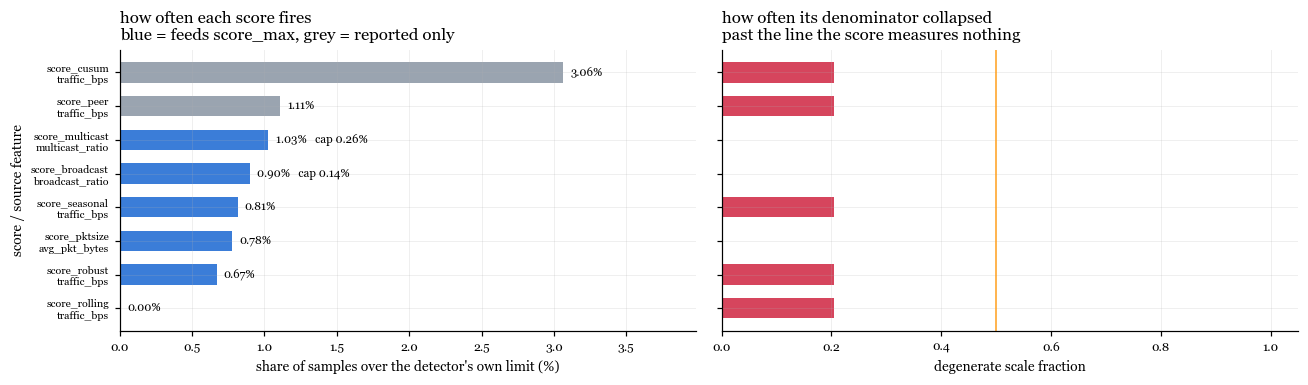

score_max over 4.0   3.47% of samples;  cusum signals 1,323 over the whole month


In [5]:
def global_scale(values):
    """Scale estimator: MAD rescaled to a Gaussian-consistent standard deviation,
    with fallbacks when the series is degenerate."""
    x = np.asarray(values, dtype=float)
    x = x[np.isfinite(x)]  # drop NaN/Inf before computing order statistics
    if x.size == 0:
        return 0.0
    mad = float(np.median(np.abs(x - np.median(x)))) * MAD_TO_SIGMA  # MAD, rescaled by the normal-consistency factor 1.4826
    if mad > 0:
        return mad  # primary estimator when non-degenerate
    std = float(np.std(x))  # fallback: population standard deviation
    return std if std > 0 else 0.01 * float(np.mean(np.abs(x)))  # final fallback: fixed fraction of mean absolute value, avoids a zero scale


def scale_floor(values, fraction=0.05):
    """Lower bound for any score denominator: a fixed fraction of the series' overall spread."""
    return max(fraction * global_scale(values), 1e-12)  # 1e-12 guards a fully constant series


def degenerate_fraction(scale, values):
    """Diagnostic: share of samples where the per-sample scale collapsed onto the
    floor, i.e. the metric is near-constant and its z-score carries no information."""
    floor = scale_floor(values)
    return float((np.asarray(scale, dtype=float) <= floor * 1.0001).mean())


def _floor_scale(scale, values, fraction=0.05):
    """Apply the floor to a per-sample scale series: fill missing values, clip below the floor."""
    floor = scale_floor(values, fraction)
    return scale.fillna(floor).clip(lower=floor)


def rolling_mean(values, window, min_periods=None):
    """Center/scale estimator: rolling arithmetic mean and rolling standard deviation."""
    mp = min_periods or max(3, window // 3)  # minimum samples required before the window is valid
    return values.rolling(window, min_periods=mp).mean(), _floor_scale(
        values.rolling(window, min_periods=mp).std(), values)


def rolling_robust(values, window, min_periods=None):
    """Center/scale estimator: rolling median and rolling MAD, both order-statistic
    based and resistant to outliers within the window."""
    mp = min_periods or max(3, window // 3)
    center = values.rolling(window, min_periods=mp).median()  # center: rolling median
    mad = (values - center).abs().rolling(window, min_periods=mp).median()  # scale: rolling median absolute deviation from that center
    return center, _floor_scale(mad * MAD_TO_SIGMA, values)  # rescale by the normal-consistency factor


def _season_key(ts, by):
    """Construct the grouping key that defines one recurring seasonal bucket."""
    if by == "hour":
        return ts.dt.hour.astype(str)  # key: hour of day
    if by == "daytype_hour":
        daytype = np.where(ts.dt.dayofweek >= 5, "weekend", "weekday")
        return pd.Series(daytype, index=ts.index) + "-" + ts.dt.hour.astype(str).str.zfill(2)  # key: weekday/weekend x hour of day
    if by == "dow_hour":
        return ts.dt.dayofweek.astype(str) + "-" + ts.dt.hour.astype(str).str.zfill(2)  # key: day of week x hour of day
    if by == "tod":
        return ts.dt.strftime("%H:%M")  # key: time of day, calendar date ignored
    raise ValueError(f"unknown seasonal key: {by}")


def seasonal(frame, value_col, by="daytype_hour", ts_col="timestamp", train_mask=None, min_samples=8):
    """Center/scale estimator: median and MAD computed within each recurring seasonal
    bucket, not over a sliding window."""
    values = frame[value_col].astype(float)
    key = _season_key(frame[ts_col], by)  # assign every sample to its seasonal bucket
    source = key if train_mask is None else key.where(train_mask)  # optionally restrict bucket statistics to a training subset
    g = values.groupby(source, observed=True)
    center_map, mad_map, counts = g.median(), g.apply(lambda s: (s - s.median()).abs().median()) * MAD_TO_SIGMA, g.size()  # per-bucket median, rescaled MAD, sample count
    thin = counts[counts < min_samples].index  # buckets with insufficient samples for a stable estimate
    center_map = center_map.drop(index=thin, errors="ignore")
    mad_map = mad_map.drop(index=thin, errors="ignore")
    center = key.map(center_map).fillna(values.median())  # per-sample center from its bucket, global median fallback for dropped buckets
    return center, _floor_scale(key.map(mad_map), values)


def peer(frame, value_col, ts_col="timestamp", unit_col="port_id", leave_one_out=True):
    """Center/scale estimator: cross-sectional median and MAD across peer units at
    each timestamp."""
    wide = frame.pivot_table(index=ts_col, columns=unit_col, values=value_col, aggfunc="mean")  # reshape to a timestamp x unit matrix
    m = wide.to_numpy(dtype=float)
    centers, scales = np.empty_like(m), np.empty_like(m)
    for j in range(m.shape[1]):
        others = np.delete(m, j, axis=1) if (leave_one_out and m.shape[1] > 1) else m  # exclude the unit's own column, leave-one-out
        med = np.nanmedian(others, axis=1)  # cross-sectional median at each timestamp
        mad = np.nanmedian(np.abs(others - med[:, None]), axis=1) * MAD_TO_SIGMA  # cross-sectional MAD, rescaled
        centers[:, j], scales[:, j] = med, mad
    cw = pd.DataFrame(centers, index=wide.index, columns=wide.columns)
    sw = pd.DataFrame(scales, index=wide.index, columns=wide.columns)
    idx = pd.MultiIndex.from_arrays([frame[ts_col], frame[unit_col]])
    center = pd.Series(cw.stack().reindex(idx).to_numpy(), index=frame.index)  # map back to the original row order
    scale = pd.Series(sw.stack().reindex(idx).to_numpy(), index=frame.index)
    return center, _floor_scale(scale, frame[value_col].astype(float))


def deviation_score(values, center, scale, signed=True, cap=MAX_SCORE):
    """Normalization step: (value - center) / scale, clipped to +/-cap."""
    s = ((values - center) / scale).clip(lower=-cap, upper=cap)  # standardized deviation, symmetric clip bounds outliers
    return s if signed else s.abs()  # signed score or its magnitude


def score_robust_z(values, window):
    """Composition: rolling median/MAD center-scale, standardized by deviation_score."""
    c, s = rolling_robust(values, window)
    return deviation_score(values, c, s)


def score_cusum(values, window, k=0.5, h=5.0, robust=True, reset_on_signal=True):
    """Change-point statistic: two-sided cumulative sum of a deadbanded standardized
    residual, normalized by the decision limit h; not a (value-center)/scale score."""
    c, s = (rolling_robust(values, window) if robust else rolling_mean(values, window))  # center/scale for the input residual
    z = ((values - c) / s).fillna(0.0).to_numpy(dtype=float)  # standardized residual feeding the CUSUM
    n = len(z)
    pos, neg, score = np.zeros(n), np.zeros(n), np.zeros(n)
    signal = np.zeros(n, dtype=bool)
    cp = cn = 0.0
    for i in range(1, n):
        pos[i] = max(0.0, cp + z[i] - k)  # upward arm: accumulate residual past the deadband k, floored at 0
        neg[i] = max(0.0, cn - z[i] - k)  # downward arm: symmetric accumulator for negative drift
        score[i] = max(pos[i], neg[i]) / h  # reported statistic, normalized by the decision limit
        crossed = pos[i] > h or neg[i] > h  # either arm exceeding h is a signal
        signal[i] = crossed
        cp, cn = (0.0, 0.0) if (crossed and reset_on_signal) else (pos[i], neg[i])  # reset both arms after a signal, or carry them forward
    return pd.DataFrame({"cusum_pos": pos, "cusum_neg": neg, "cusum_score": score,
                         "cusum_signal": signal}, index=values.index)


def truth_mask(frame, events):
    """Boolean per-sample ground truth aligned to `frame`."""
    mask = pd.Series(False, index=frame.index)
    for e in events.itertuples():
        mask |= ((frame["port_id"] == e.port_id) & (frame["timestamp"] >= e.start)
                 & (frame["timestamp"] <= e.end))
    return mask

# The line the dashboard draws, and the threshold Layer 2 will apply.
# Section 5 sweeps it. This is the one place to change it.
THRESHOLD = 4.0
CUSUM_LIMIT = 1.0

frames = []
for pid, grp in tel.groupby("port_id", observed=True):
    g = grp.sort_values("timestamp").reset_index(drop=True)

    rc, rs = rolling_mean(g["traffic_bps"], W)
    g["roll_center"], g["roll_lo"], g["roll_hi"] = rc, rc - 3 * rs, rc + 3 * rs
    bc, bs = rolling_robust(g["traffic_bps"], W)
    g["robust_center"], g["robust_lo"], g["robust_hi"] = bc, bc - 3 * bs, bc + 3 * bs
    sc, ss = seasonal(g, "traffic_bps", by="daytype_hour")
    g["seasonal_center"], g["seasonal_lo"], g["seasonal_hi"] = sc, sc - 3 * ss, sc + 3 * ss

    g["score_rolling"] = deviation_score(g["traffic_bps"], rc, rs)
    g["score_robust"] = deviation_score(g["traffic_bps"], bc, bs)
    g["score_seasonal"] = deviation_score(g["traffic_bps"], sc, ss)
    g["score_broadcast"] = score_robust_z(g["broadcast_ratio"], W)
    g["score_multicast"] = score_robust_z(g["multicast_ratio"], W)
    g["score_pktsize"] = score_robust_z(g["avg_pkt_bytes"], W)
    g = g.join(score_cusum(g["traffic_bps"], W))
    frames.append(g)

allp = pd.concat(frames, ignore_index=True)

pc, ps = peer(allp, "traffic_bps")
allp["peer_center"], allp["peer_lo"], allp["peer_hi"] = pc, pc - 3 * ps, pc + 3 * ps
allp["score_peer"] = deviation_score(allp["traffic_bps"], pc, ps)
# The dashboard queries score_cusum; rename once rather than ship two identical columns.
allp = allp.rename(columns={"cusum_score": "score_cusum"})

SCORES = ["score_robust", "score_seasonal", "score_broadcast", "score_multicast", "score_pktsize"]
allp["score_max"] = allp[SCORES].abs().max(axis=1)
allp["is_incident"] = truth_mask(allp, incidents).astype(float)
allp["is_planned"] = truth_mask(allp, planned).astype(float)

# ---- profile of what this lab will detect on --------------------------------
SCORE_SOURCE = {
    "score_robust": "traffic_bps", "score_seasonal": "traffic_bps",
    "score_broadcast": "broadcast_ratio", "score_multicast": "multicast_ratio",
    "score_pktsize": "avg_pkt_bytes", "score_rolling": "traffic_bps",
    "score_peer": "traffic_bps", "score_cusum": "traffic_bps",
}

degen = {}
for feat in dict.fromkeys(SCORE_SOURCE.values()):
    per_port = []
    for _, g in allp.groupby("port_id", observed=True):
        values = g[feat].reset_index(drop=True)
        _, scale = rolling_robust(values, W)
        per_port.append(degenerate_fraction(scale, values))
    degen[feat] = float(np.mean(per_port))

inv = (allp.groupby(["device_id", "port_id", "port_role"], observed=True)
           .agg(samples=("timestamp", "size"), traffic=("traffic_bps", "median"),
                packets_pps_median=("packets_pps", "median")).reset_index())
inv["traffic_kBs_median"] = (inv.pop("traffic") / 1000).round(1)
inv["packets_pps_median"] = inv["packets_pps_median"].round(1)
print("port inventory")
print(inv.to_string(index=False))

steps = (allp.sort_values(["port_id", "timestamp"])
             .groupby("port_id", observed=True)["timestamp"].diff().dt.total_seconds().dropna())
print()
print("coverage and class balance")
print(f"  samples                      {len(allp):>8,}")
print(f"  sampling steps other than {CADENCE:.0f}s  {int((steps != CADENCE).sum()):>3}")
print(f"  inside an incident window    {int(allp['is_incident'].sum()):>8,}   "
      f"{allp['is_incident'].mean():.2%} of samples")
print(f"  inside a planned change      {int(allp['is_planned'].sum()):>8,}   "
      f"{allp['is_planned'].mean():.2%} of samples")

ev_inv = events.copy()
ev_inv["planned"] = ev_inv["event_id"].isin(set(planned["event_id"]))
ev_inv = (ev_inv.groupby(["event_id", "event_type", "planned"], observed=True)
                .agg(ports=("port_id", "nunique"), start=("start", "min"),
                     end=("end", "max"), points=("n_points", "sum")).reset_index())
ev_inv["minutes"] = (ev_inv["points"] / ev_inv["ports"] * CADENCE / 60).round(0).astype(int)
print()
print("event inventory")
print(ev_inv.to_string(index=False))

PUBLISHED = ["traffic_bps", "packets_pps", "error_rate", "discard_rate", "errors_pps",
             "avg_pkt_bytes", "broadcast_ratio", "multicast_ratio"]
raw = []
for feat in PUBLISHED:
    col = allp[feat].astype(float)
    # Ratios and rates need more decimals than bytes per second to stay readable.
    d = 1 if col.max() >= 100 else (3 if col.max() >= 1 else 5)
    raw.append({
        "feature": feat,
        "nulls": int(col.isna().sum()),
        "zero_frac": f"{float((col == 0).mean()):.2%}",
        "min": f"{col.min():,.{d}f}",
        "median": f"{col.median():,.{d}f}",
        "p95": f"{col.quantile(0.95):,.{d}f}",
        "max": f"{col.max():,.{d}f}",
    })
print()
print("raw features this lab publishes, five ports pooled")
print(pd.DataFrame(raw).to_string(index=False))

rows = []
for col, feat in SCORE_SOURCE.items():
    limit = CUSUM_LIMIT if col == "score_cusum" else THRESHOLD
    s = allp[col].abs()
    rows.append({"score": col, "source": feat, "in_score_max": col in SCORES,
                 "over_limit": float((s > limit).mean()),
                 "at_cap": float((s >= 49.99).mean()),
                 "degen_frac": degen[feat]})
prof = pd.DataFrame(rows).sort_values("over_limit")

fig, axes = plt.subplots(1, 2, figsize=(12, 3.6), sharey=True)
y = np.arange(len(prof))

axes[0].barh(y, prof["over_limit"] * 100, height=0.6,
             color=[PALETTE["signal"] if m else PALETTE["muted"] for m in prof["in_score_max"]])
for n, r in enumerate(prof.itertuples()):
    extra = f"   cap {r.at_cap:.2%}" if r.at_cap > 0 else ""
    axes[0].text(r.over_limit * 100 + 0.05, n, f"{r.over_limit:.2%}{extra}",
                 va="center", fontsize=7.5)
axes[0].set_yticks(y)
axes[0].set_yticklabels([f"{r.score}\n{r.source}" for r in prof.itertuples()], fontsize=7)
axes[0].set_xlim(0, prof["over_limit"].max() * 130)
axes[0].set_xlabel("share of samples over the detector's own limit (%)")
axes[0].set_ylabel("score / source feature")
axes[0].set_title("how often each score fires\nblue = feeds score_max, grey = reported only")

axes[1].barh(y, prof["degen_frac"], height=0.6, color=PALETTE["alert"])
axes[1].axvline(0.5, color=PALETTE["truth"], lw=1.0)
axes[1].set_xlim(0, 1.05)
axes[1].set_xlabel("degenerate scale fraction")
axes[1].set_title("how often its denominator collapsed\npast the line the score measures nothing")
fig.tight_layout()
plt.show()

print(f"score_max over {THRESHOLD}   {float((allp['score_max'] > THRESHOLD).mean()):.2%} of samples;  "
      f"cusum signals {int(allp['cusum_signal'].sum()):,} over the whole month")

## 1. 三層架構與多維分數計算
偵測方法分為三大類：

1. **固定閾值（Static Thresholds）：** 判定指標是否越過明確的工程邊界。
2. **統計 Baseline（Statistical Baselines）：** 判定指標離歷史常態的偏離程度。
3. **水位位移（Change Point Detection）：** 判定均值水位是否產生結構性位移。

`score_max` 是 Lab 01 §6 那套十一特徵組合分數原封不動搬過來的；CUSUM 在這裡跟 Peer 一樣，是主分數之外另外保留的一個視角，回答的是「有沒有慢慢累積」，不是「現在偏離多少」，只報告不進政策。

### 數據剖面與特性分析

* **分母崩潰（Degenerate Scale）：** 若特徵的偏離尺度（如 MAD）極小或趨近於零，分母會收斂至底線常數（Floor Constant）。此時輸出的 Z-score 不再具備統計意義，僅反映底線數值的大小。
* **Robust vs. Standard Rolling Z-Score：** 使用 Rolling Mean/Std 計算的 Z-score 在全域最大值可能極低（例如僅達 $3.2$），而同一段流量使用 Rolling Median/MAD（Robust Z-score）則可達到 $40.0$ 以上。原因在於標準差會被異常尖峰拉高，進而抑制後續的偏離分數；MAD 則具備抗污染特性。
* **類別極不平衡：** 未申報的故障事故（Incidents）樣本僅佔總資料量的 0.52%。正負樣本相差兩個數量級，因此單點 Accuracy 無法作為評估依據。

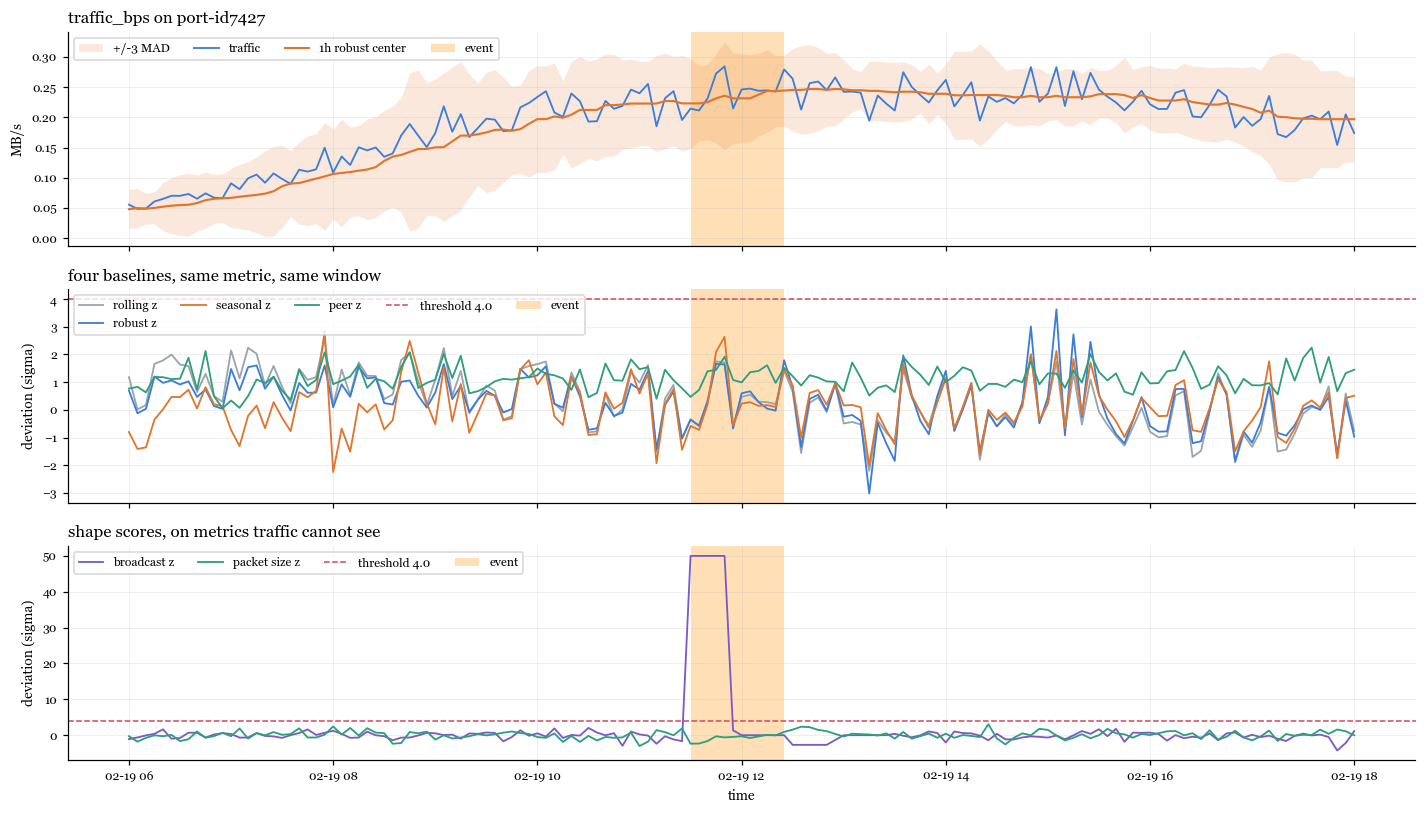

In [6]:
def shade_truth(ax, time, mask, color=None, alpha=0.32, legend="event"):
    """Shade contiguous True runs of a boolean mask as one legend entry."""
    color = PALETTE["truth"] if color is None else color
    values = np.asarray(pd.Series(mask).fillna(False), dtype=bool)
    idx = np.flatnonzero(values)
    if idx.size == 0:
        return
    brk = np.flatnonzero(np.diff(idx) > 1)
    starts = np.concatenate([[idx[0]], idx[brk + 1]])
    ends = np.concatenate([idx[brk], [idx[-1]]])
    time = pd.Series(time).reset_index(drop=True)
    for n, (a, b) in enumerate(zip(starts, ends)):
        ax.axvspan(time.iloc[a], time.iloc[b], color=color, alpha=alpha,
                   linewidth=0, zorder=0, label=legend if n == 0 else None)

STORM_PORT = "port-id7427"
STORM_FROM, STORM_TO = "2026-02-19 06:00", "2026-02-19 18:00"


def storm_window():
    """這一節反覆看同一段，取出來的動作寫成一個函式，免得每次重打一次條件。"""
    hit = ((allp["port_id"] == STORM_PORT)
           & (allp["timestamp"] >= STORM_FROM)
           & (allp["timestamp"] <= STORM_TO))
    return allp[hit].reset_index(drop=True)


look = storm_window()
fig, axes = plt.subplots(3, 1, figsize=(13, 7.5), sharex=True)

axes[0].fill_between(look["timestamp"], look["robust_lo"] / 1e6, look["robust_hi"] / 1e6,
                     color="#E0752D", alpha=0.16, lw=0, label="+/-3 MAD")
axes[0].plot(look["timestamp"], look["traffic_bps"] / 1e6,
             color="#3B7DD8", lw=1.2, label="traffic")
axes[0].plot(look["timestamp"], look["robust_center"] / 1e6,
             color="#E0752D", lw=1.4, label="1h robust center")
axes[0].set_title(f"traffic_bps on {STORM_PORT}", loc="left", fontsize=11)
axes[0].set_ylabel("MB/s", fontsize=9)

for column, legend, color in [("score_rolling", "rolling z", "#9AA4B0"),
                              ("score_robust", "robust z", "#3B7DD8"),
                              ("score_seasonal", "seasonal z", "#E0752D"),
                              ("score_peer", "peer z", "#2E9E7B")]:
    axes[1].plot(look["timestamp"], look[column], color=color, lw=1.2, label=legend)
axes[1].set_title("four baselines, same metric, same window", loc="left", fontsize=11)

for column, legend, color in [("score_broadcast", "broadcast z", "#7A5AC7"),
                              ("score_pktsize", "packet size z", "#2E9E7B")]:
    axes[2].plot(look["timestamp"], look[column], color=color, lw=1.2, label=legend)
axes[2].set_title("shape scores, on metrics traffic cannot see", loc="left", fontsize=11)
axes[2].set_xlabel("time")
axes[2].set_ylabel("deviation (sigma)")

for ax in axes[1:]:
    ax.axhline(THRESHOLD, color="#D6455D", ls="--", lw=1.0, label=f"threshold {THRESHOLD}")
    ax.set_ylabel("deviation (sigma)", fontsize=9)

for ax in axes:
    shade_truth(ax, look["timestamp"], look["is_incident"])
    ax.legend(fontsize=8, loc="upper left", ncol=5)
    ax.grid(alpha=0.22, lw=0.6)
    for side in ("top", "right"):
        ax.spines[side].set_visible(False)
fig.tight_layout()
plt.show()

### **消融實驗（Ablation Study）:**

* Parameter：`THRESHOLD`（4.0）與 `CUSUM_LIMIT`（1.0），兩條閾值線目前是全域共用的常數。
* Architecture：`SCORES` 決定哪幾條 z 進 `score_max`；peer 與 CUSUM 只報告不進政策，這條界線也是設計決定。
* Per-port：全部 5 個 port 共用同一個 `THRESHOLD`；Lab 01 §4 已經看到不同 port 流量差一個數量級，閾值不一定該一樣。

### 1b. CUSUM (累積和演算法)

CUSUM（Cumulative Sum）適合用於偵測持續性的微小位移（Change Point）。與逐點無記憶的 Z-score 不同，CUSUM 會將超過死區（Deadband $k$）的標準化殘差進行累加，一旦累加值超過決策界線 $h$ 即觸發訊號並歸零。

$$\text{CUSUM}^+ = \max(0, \text{CUSUM}^+_{t-1} + z_t - k)$$

* **參數設定：** $k$ 通常設定為 $0.5$（對應偵測 $1\sigma$ 的位移）；$h$ 控制決策界線，值越大則延遲越長但誤報率越低。
* **限制條件：** 若 CUSUM 的輸入殘差來自已被污染的 Rolling Baseline，當 Baseline 隨流量抬升追上實際數值時，CUSUM 將同樣失去偵測能力。

In [7]:
# Event A ramp, minute by minute: robust z keeps re-triggering and clearing
# as the baseline catches up to the rising traffic, while CUSUM's accumulated
# residual keeps climbing across the same samples. Same data, two different
# memories.
ramp = allp[(allp["port_id"] == "port-id7430")
            & (allp["timestamp"] >= "2026-02-04 08:50")
            & (allp["timestamp"] <= "2026-02-04 09:45")]

print("event A business_traffic_growth on port-id7430, the ramp starts at 09:00")
print(pd.DataFrame({
    "time": ramp["timestamp"].dt.strftime("%H:%M"),
    "traffic_kBs": (ramp["traffic_bps"] / 1000).round(0),
    "baseline_kBs": (ramp["robust_center"] / 1000).round(0),
    "robust_z": ramp["score_robust"].round(2),
    "cusum": ramp["score_cusum"].round(2),
    "cusum_signal": ramp["cusum_signal"],
}).to_string(index=False))

over_z = ramp.loc[ramp["score_robust"].abs() > THRESHOLD, "timestamp"].dt.strftime("%H:%M").tolist()
over_c = ramp.loc[ramp["cusum_signal"], "timestamp"].dt.strftime("%H:%M").tolist()
print()
print(f"robust z over its {THRESHOLD}    {over_z}")
print(f"cusum over its {CUSUM_LIMIT}       {over_c}")

event A business_traffic_growth on port-id7430, the ramp starts at 09:00
 time  traffic_kBs  baseline_kBs  robust_z  cusum  cusum_signal
08:50         66.0          63.0      0.20   0.69         False
08:55         70.0          65.0      0.41   0.67         False
09:00        131.0          67.0      4.73   1.52          True
09:05        162.0          67.0      7.00   1.30          True
09:10        130.0          69.0      3.33   0.57         False
09:15        125.0          71.0      2.93   1.05          True
09:20        140.0          73.0      3.37   0.57         False
09:25        171.0         100.0      1.36   0.75         False
09:30        140.0         127.0      0.25   0.69         False
09:35        163.0         130.0      0.51   0.70         False
09:40        187.0         135.0      0.66   0.73         False
09:45        135.0         137.0     -0.03   0.62         False

robust z over its 4.0    ['09:00', '09:05']
cusum over its 1.0       ['09:00', '09:05', '09:15

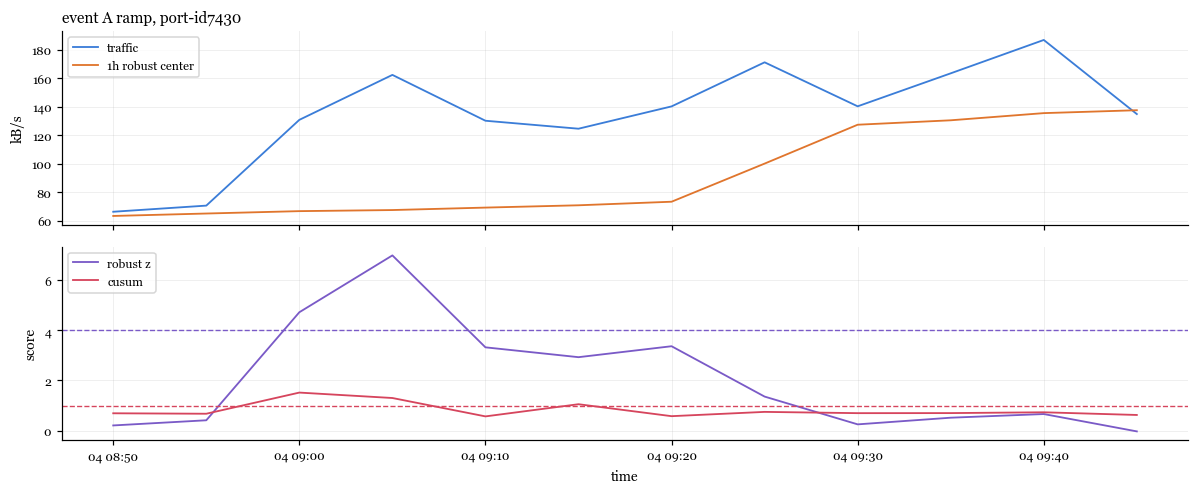

In [8]:
# Same ramp as above, plotted: the baseline (dashed) visibly bends toward the
# rising traffic, which is the mechanism behind robust z's repeated
# trigger/clear cycles in the printed table.
fig, axes = plt.subplots(2, 1, figsize=(11, 4.6), sharex=True)

axes[0].plot(ramp["timestamp"], ramp["traffic_bps"] / 1000, color=PALETTE["signal"], lw=1.2, label="traffic")
axes[0].plot(ramp["timestamp"], ramp["robust_center"] / 1000, color=PALETTE["baseline"], lw=1.2, label="1h robust center")
axes[0].set_ylabel("kB/s")
axes[0].set_title("event A ramp, port-id7430", loc="left", fontsize=10)
axes[0].legend(fontsize=8, loc="upper left")

axes[1].plot(ramp["timestamp"], ramp["score_robust"], color=PALETTE["score"], lw=1.2, label="robust z")
axes[1].plot(ramp["timestamp"], ramp["score_cusum"], color=PALETTE["alert"], lw=1.2, label="cusum")
axes[1].axhline(THRESHOLD, color=PALETTE["score"], ls="--", lw=0.9)
axes[1].axhline(CUSUM_LIMIT, color=PALETTE["alert"], ls="--", lw=0.9)
axes[1].set_xlabel("time")
axes[1].set_ylabel("score")
axes[1].legend(fontsize=8, loc="upper left")

for ax in axes:
    ax.grid(alpha=0.22, lw=0.6)
    for side in ("top", "right"):
        ax.spines[side].set_visible(False)
fig.tight_layout()
plt.show()

### **消融實驗（Ablation Study）:**

* Parameter：`k`（死區，預設 0.5）與 `h`（決策界線，預設 5.0），呼叫 `score_cusum()` 時可以覆寫。
* Architecture：`robust=True` 決定 CUSUM 讀的殘差來自 robust baseline 還是 rolling mean；`reset_on_signal` 決定觸發後要不要歸零。
* Per-port：目前所有 port 共用同一組 `k`／`h`；累積速度不同的 port，死區大小應該不同。

## 1c. 多重檢定與有效樣本數：閾值 4.0 不是單純的尾端機率
常態假設下 $|z|>4$ 的尾端機率是個很小的數字，但 `score_max` 實測的越線比例遠高於它。差距來自三個效應疊加：流量分佈重尾、MAD 在安靜時段塌到下限把分數推高、樣本之間高度自相關讓一次事件貢獻連續好幾筆越線。

In [9]:
from scipy.stats import norm

breach_rate = float((allp["score_max"] > THRESHOLD).mean())
gauss_tail = 2 * (1 - norm.cdf(THRESHOLD))
cheby_bound = 1 / THRESHOLD ** 2

print(f"常態假設下 |z| > {THRESHOLD:g} 的尾端機率   {gauss_tail:.2e}")
print(f"Chebyshev 上界 (1/k^2)                  {cheby_bound:.4f}")
print(f"實測 score_max 越線比例                  {breach_rate:.4f}")
print(f"實測 / 常態預測                          {breach_rate / gauss_tail:,.0f} 倍")
print("Chebyshev 涵蓋了實測，常態表差了好幾個數量級。"
      "資料重尾、MAD 塌到下限、樣本自相關三者疊加，才把實測推到這裡。")

s1 = tel[tel["port_id"] == "port-id7429"].sort_values("timestamp")["traffic_bps"]
rho = float(s1.autocorr(lag=1))
n_eff = len(s1) * (1 - rho) / (1 + rho)
print()
print(f"port-id7429 traffic_bps 的 lag-1 自相關 rho = {rho:.3f}")
print(f"n_eff = n(1-rho)/(1+rho) 約等於 n / {1 / ((1 - rho) / (1 + rho)):.0f}")
print(f"{len(s1):,} 筆樣本約等於 {n_eff:,.0f} 筆獨立觀測")

m = 8 * 5 * int(round(86400 / CADENCE * 30))
bonf = 0.05 / m
print()
print(f"8 個候選特徵 x 5 個 port x 一個月的取樣點 約 {m:,} 次判定")
print(f"Bonferroni alpha/m = {bonf:.1e}，換算成常態閾值 |z| > {norm.ppf(1 - bonf / 2):.2f}")
print("實務上把誤報與漏抓合成每天幾則告警一個量，比單獨修正顯著水準更貼近維運決策。"
      "這正是 Part K 記分卡在做的事，自動吸收了自相關與多重檢定。")

常態假設下 |z| > 4 的尾端機率   6.33e-05
Chebyshev 上界 (1/k^2)                  0.0625
實測 score_max 越線比例                  0.0347
實測 / 常態預測                          548 倍
Chebyshev 涵蓋了實測，常態表差了好幾個數量級。資料重尾、MAD 塌到下限、樣本自相關三者疊加，才把實測推到這裡。

port-id7429 traffic_bps 的 lag-1 自相關 rho = 0.965
n_eff = n(1-rho)/(1+rho) 約等於 n / 57
8,640 筆樣本約等於 152 筆獨立觀測

8 個候選特徵 x 5 個 port x 一個月的取樣點 約 345,600 次判定
Bonferroni alpha/m = 1.4e-07，換算成常態閾值 |z| > 5.26
實務上把誤報與漏抓合成每天幾則告警一個量，比單獨修正顯著水準更貼近維運決策。這正是 Part K 記分卡在做的事，自動吸收了自相關與多重檢定。


## 1d. EWMA：另一種給偵測器記憶的方法
給偵測器記憶不是只有 CUSUM 一種做法。EWMA（指數加權移動平均）對舊資料的權重按幾何級數衰減，`lambda` 越大，記憶越短。下面用事件 D（`queue_congestion`，急漲急落的壅塞）示範：z 沒有記憶，單一取樣衝到高點就立刻回落；EWMA 反應慢，但峰值出現得晚、消退也晚，這是記憶換來的靈敏度，代價落在同一個地方。

/var/folders/x7/7zwx0z0d7jj_2s9ndx3lg7200000gn/T/ipykernel_53144/648679092.py:29: UserWarning: Glyph 65292 (\N{FULLWIDTH COMMA}) missing from font(s) Georgia.
  fig.tight_layout()
/var/folders/x7/7zwx0z0d7jj_2s9ndx3lg7200000gn/T/ipykernel_53144/648679092.py:29: UserWarning: Glyph 27794 (\N{CJK UNIFIED IDEOGRAPH-6C92}) missing from font(s) Georgia.
  fig.tight_layout()
/var/folders/x7/7zwx0z0d7jj_2s9ndx3lg7200000gn/T/ipykernel_53144/648679092.py:29: UserWarning: Glyph 26377 (\N{CJK UNIFIED IDEOGRAPH-6709}) missing from font(s) Georgia.
  fig.tight_layout()
/var/folders/x7/7zwx0z0d7jj_2s9ndx3lg7200000gn/T/ipykernel_53144/648679092.py:29: UserWarning: Glyph 35352 (\N{CJK UNIFIED IDEOGRAPH-8A18}) missing from font(s) Georgia.
  fig.tight_layout()
/var/folders/x7/7zwx0z0d7jj_2s9ndx3lg7200000gn/T/ipykernel_53144/648679092.py:29: UserWarning: Glyph 25014 (\N{CJK UNIFIED IDEOGRAPH-61B6}) missing from font(s) Georgia.
  fig.tight_layout()
/var/folders/x7/7zwx0z0d7jj_2s9ndx3lg7200000gn/T/ipykern

/opt/miniconda3/envs/aiops-anomaly-zero-to-hero/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 65292 (\N{FULLWIDTH COMMA}) missing from font(s) Georgia.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/miniconda3/envs/aiops-anomaly-zero-to-hero/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 27794 (\N{CJK UNIFIED IDEOGRAPH-6C92}) missing from font(s) Georgia.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/miniconda3/envs/aiops-anomaly-zero-to-hero/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 26377 (\N{CJK UNIFIED IDEOGRAPH-6709}) missing from font(s) Georgia.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/miniconda3/envs/aiops-anomaly-zero-to-hero/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 35352 (\N{CJK UNIFIED IDEOGRAPH-8A18}) missing from font(s) Georgia.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/miniconda3/envs/aiops-anomaly-zero-to-hero/lib/pyt

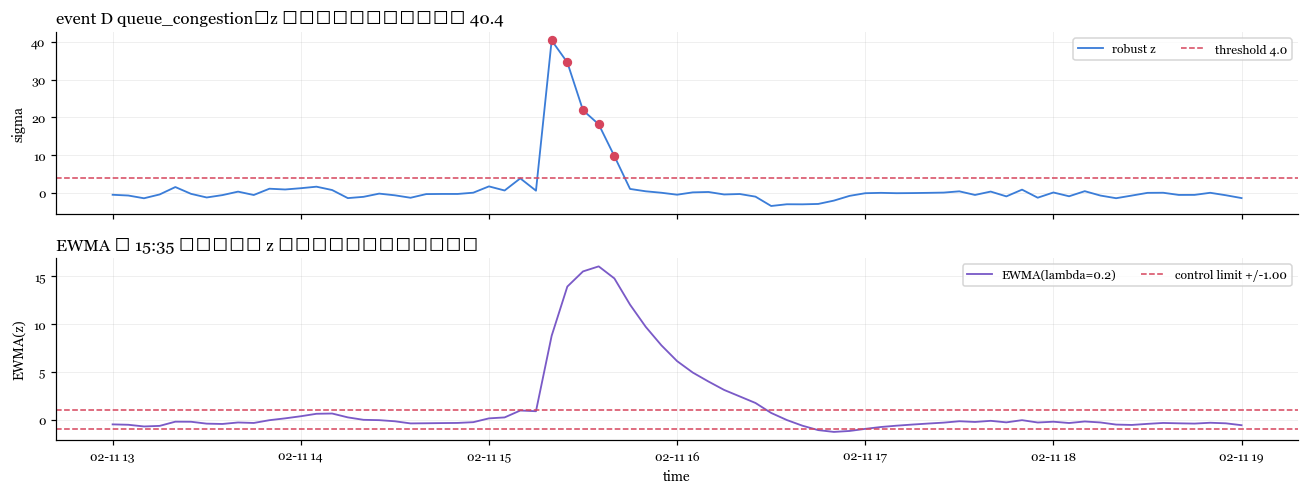

z 峰值 40.4，EWMA 峰值 16.05，出現在 15:35


In [10]:
# Event D is a short, sharp spike, not a slow ramp, so this window shows
# EWMA's cost plainly: it peaks later than the raw z-score and stays
# elevated longer after the raw score has already fallen back near zero.
w = allp[(allp["port_id"] == "port-id7427")
         & (allp["timestamp"] >= "2026-02-11 13:00")
         & (allp["timestamp"] <= "2026-02-11 19:00")].reset_index(drop=True)
lam = 0.2
w["ewma_z"] = w["score_robust"].ewm(alpha=lam, adjust=False).mean()
L = 3.0
limit = L * np.sqrt(lam / (2 - lam))

fig, axes = plt.subplots(2, 1, figsize=(12, 4.6), sharex=True)
axes[0].plot(w["timestamp"], w["score_robust"], color=PALETTE["signal"], lw=1.2, label="robust z")
axes[0].axhline(THRESHOLD, color=PALETTE["alert"], ls="--", lw=1.0, label=f"threshold {THRESHOLD}")
over = w[w["score_robust"].abs() > THRESHOLD]
axes[0].scatter(over["timestamp"], over["score_robust"], s=26, color=PALETTE["alert"], zorder=5)
axes[0].set_ylabel("sigma")
axes[0].legend(fontsize=8, ncol=2)
axes[0].set_title(f"event D queue_congestion，z 沒有記憶，單一瞬間衝到 {w['score_robust'].max():.1f}")

axes[1].plot(w["timestamp"], w["ewma_z"], color=PALETTE["score"], lw=1.2, label=f"EWMA(lambda={lam})")
axes[1].axhline(limit, color=PALETTE["alert"], ls="--", lw=1.0, label=f"control limit +/-{limit:.2f}")
axes[1].axhline(-limit, color=PALETTE["alert"], ls="--", lw=1.0)
axes[1].set_xlabel("time")
axes[1].set_ylabel("EWMA(z)")
axes[1].legend(fontsize=8, ncol=2)
peak_t = w.loc[w["ewma_z"].idxmax(), "timestamp"]
axes[1].set_title(f"EWMA 在 {peak_t:%H:%M} 才到頂，比 z 的尖峰晚，回到底線也晚了")
fig.tight_layout()
plt.show()

print(f"z 峰值 {w['score_robust'].max():.1f}，EWMA 峰值 {w['ewma_z'].max():.2f}，出現在 {peak_t:%H:%M}")

## 2. 邊界條件與特徵無效分析
在以 Z-score 為主的多特徵模型中，若特定指標（如 `errors_pps` 或 `error_rate`）超過 97% 的樣本皆為零，其滾動離散度（Scale）會直接塌陷至底線。此時 Z-score 無法提供任何鑑別力。

對比分析：

* **統計 Z-Score 模式：** 塌陷的分母導致任何微小的非零數值均被截斷至最大值限制（`MAX_SCORE = 50.0`），失去物理量測意義。
* **固定絕對門檻模式：** 套用固定規則 `errors_pps > 0.05` 能精準切分真正的 Link Quality 故障點，背景正常樣本的最大值僅為 $0.0000$，訊號與背景具備極高分離度。

**原則：** 當指標具備明確且可知的工程物理邊界（如零錯誤率），應優先採用固定閾值；統計分數在此類指標上無法提供額外的偵測能力。

In [11]:
# Port-id7429 is where event E (link_quality_issue) lands: this profiles
# which candidate features still have a meaningful scale there versus which
# have collapsed, ahead of picking a fixed threshold instead of a z-score.
def single_port(telemetry, port_id=None):
    if port_id is None:
        port_id = telemetry["port_id"].value_counts().index[0]
    return telemetry[telemetry["port_id"] == port_id].sort_values("timestamp").reset_index(drop=True)

FEATURES = ["traffic_bps", "error_rate", "discard_rate", "broadcast_ratio",
            "multicast_ratio", "avg_pkt_bytes", "unknown_proto_pps"]

# Four of these already carry a robust z on every port from the profile cell.
STORED_Z = {"traffic_bps": "score_robust", "broadcast_ratio": "score_broadcast",
            "multicast_ratio": "score_multicast", "avg_pkt_bytes": "score_pktsize"}

p9 = single_port(tel, "port-id7429")
z9 = allp[allp["port_id"] == "port-id7429"]
rows = []
for feat in FEATURES:
    center, scale = rolling_robust(p9[feat], W)
    stored = STORED_Z.get(feat)
    z = z9[stored] if stored else deviation_score(p9[feat], center, scale)
    rows.append({
        "feature": feat,
        "degenerate_fraction": round(degenerate_fraction(scale, p9[feat]), 3),
        "exactly_zero_fraction": round(float((p9[feat] == 0).mean()), 3),
        "max_abs_z": round(float(z.abs().max()), 1),
    })
print("port-id7429, the port event E lands on")
print(pd.DataFrame(rows).to_string(index=False))

# What the fixed rule sees instead. Same metric, no statistics, one hard number.
hot = allp[allp["errors_pps"] > 0.05]
print()
print(f"samples over the fixed rule errors_pps > 0.05:  {len(hot)} of {len(allp):,}")
print(hot.groupby("event_label", observed=True).size().to_string())
print(f"highest errors_pps outside any labelled event:  "
      f"{allp.loc[allp['event_label'] == 'normal', 'errors_pps'].max():.4f}")

port-id7429, the port event E lands on
          feature  degenerate_fraction  exactly_zero_fraction  max_abs_z
      traffic_bps                0.209                  0.000        9.0
       error_rate                0.998                  0.975       50.0
     discard_rate                0.995                  0.914       50.0
  broadcast_ratio                0.001                  0.000       50.0
  multicast_ratio                0.001                  0.000       50.0
    avg_pkt_bytes                0.001                  0.000       29.9
unknown_proto_pps                1.000                  0.987       50.0

samples over the fixed rule errors_pps > 0.05:  20 of 43,200
event_label
link_quality_issue            8
load_sensitive_link_issue    12
highest errors_pps outside any labelled event:  0.0100


In [12]:
# 固定閾值的分離度。先猜，再跑，再把 LIMIT 改成 0.01 和 0.5 各跑一次。
LIMIT = 0.05

hit = allp["errors_pps"] > LIMIT
normal = allp["is_incident"] == 0
print(f"閾值 errors_pps > {LIMIT}")
print(f"  超標樣本            {int(hit.sum()):>6,} / {len(allp):,}")
print(f"  超標樣本落在真值時窗內  {allp.loc[hit, 'is_incident'].mean():.3f}   (1.000 = 零誤報)")
print(f"  正常樣本的最大值     {allp.loc[normal, 'errors_pps'].max():.4f}")
print(f"  超標樣本的中位數     {allp.loc[hit, 'errors_pps'].median():.4f}")
print()
print("訊號與背景之間差幾倍：",
      f"{allp.loc[hit, 'errors_pps'].median() / allp.loc[normal, 'errors_pps'].max():.0f}x")

閾值 errors_pps > 0.05
  超標樣本                20 / 43,200
  超標樣本落在真值時窗內  1.000   (1.000 = 零誤報)
  正常樣本的最大值     0.0100
  超標樣本的中位數     1.7017

訊號與背景之間差幾倍： 170x


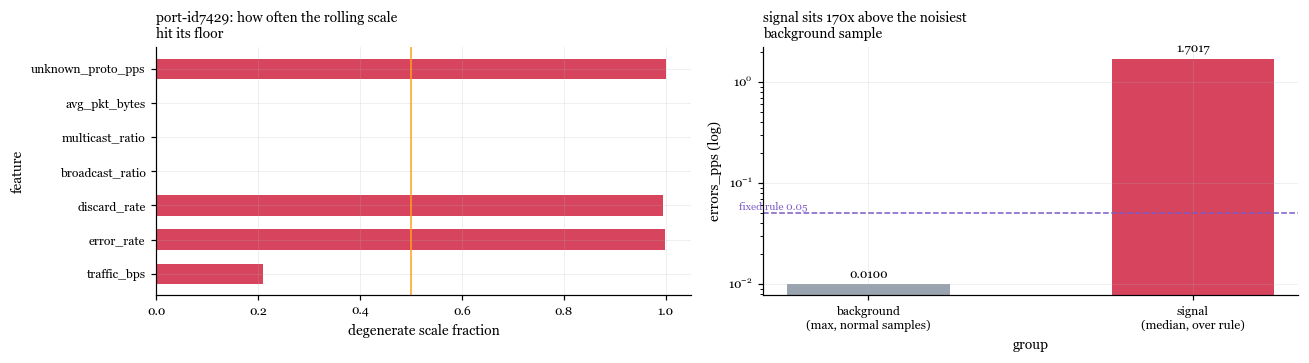

In [13]:
# Left: how often the rolling scale for each feature hit its floor on this
# port -- a diagnostic for whether a z-score means anything at all. Right:
# the fixed-rule alternative, showing the signal/background gap a statistical
# score cannot access once the denominator has collapsed.
prof = pd.DataFrame(rows)

fig, axes = plt.subplots(1, 2, figsize=(12, 3.4))

axes[0].barh(range(len(prof)), prof["degenerate_fraction"], color=PALETTE["alert"], height=0.6)
axes[0].axvline(0.5, color=PALETTE["truth"], lw=1.0)
axes[0].set_yticks(range(len(prof)))
axes[0].set_yticklabels(prof["feature"], fontsize=8)
axes[0].set_xlim(0, 1.05)
axes[0].set_xlabel("degenerate scale fraction")
axes[0].set_ylabel("feature")
axes[0].set_title("port-id7429: how often the rolling scale\nhit its floor", loc="left", fontsize=9)

bg_max = allp.loc[normal, "errors_pps"].max()
sig_med = allp.loc[hit, "errors_pps"].median()
comparison = pd.Series({"background\n(max, normal samples)": bg_max,
                        "signal\n(median, over rule)": sig_med})
axes[1].bar(range(len(comparison)), comparison.to_numpy(),
            color=[PALETTE["muted"], PALETTE["alert"]], width=0.5)
axes[1].set_yscale("log")
axes[1].set_xticks(range(len(comparison)))
axes[1].set_xticklabels(comparison.index, fontsize=8)
for n, v in enumerate(comparison.to_numpy()):
    axes[1].text(n, v * 1.15, f"{v:.4f}", ha="center", fontsize=8)
axes[1].axhline(LIMIT, color=PALETTE["score"], ls="--", lw=1.0)
axes[1].text(-0.4, LIMIT * 1.1, f"fixed rule {LIMIT}", fontsize=7, color=PALETTE["score"])
axes[1].set_xlabel("group")
axes[1].set_ylabel("errors_pps (log)")
axes[1].set_title(f"signal sits {sig_med / bg_max:.0f}x above the noisiest\nbackground sample", loc="left", fontsize=9)

for ax in axes:
    ax.grid(alpha=0.22, lw=0.6)
    for side in ("top", "right"):
        ax.spines[side].set_visible(False)
fig.tight_layout()
plt.show()

### **消融實驗（Ablation Study）:**

* Parameter：`LIMIT`（0.05），固定規則的門檻。
* Architecture：`STORED_Z` 決定哪些特徵重用第 1 節已經算好的 z、哪些現場重算；這個對照表本身是一個設計決定。
* Per-port：這裡只示範 `port-id7429`；`LIMIT` 對其他 port 不一定適用，第 4 節評估用的仍是全域共用的 0.05。

## 3. 第 6、7 步：從數字到決策，從決策到通知
`score_max` breach 掉了 1,500 個樣本（3.47%）；連續 2 筆確認後剩下 437 個 label（1.01%）；再經過 Gap Merge 與變更日曆抑制，最後 182 則真正發出通知。這一節走完後兩段轉換，每一段砍掉的量都是刻意的：不是雜訊自己消失了，是有名字的規則在篩。

### Layer 2: 門檻觸發與連續確認 (Confirm)

`confirm()` 函式將連續的偏離分數轉化為二元判定：

* `breach`：偏離分數超過閾值的單點樣本（Score $>$ Threshold）。
* `label`：分數必須**連續 $N$ 筆**（如 $N=2$）超過閾值才被確認的樣本。

連續確認能有效過濾單點脈衝雜訊（Spikes），代價是引入固定延遲：

$$\text{Latency} = (N - 1) \times \text{Cadence}$$

對於 300 秒取樣間隔，$N=2$ 代表引入 5 分鐘的物理延遲。

### Layer 3: 營運策略 (Alert Policy)

由 Label 轉化為 Alert 的過渡階段需套用以下營運條件：

1. **最小流量門檻（Min Volume Gate）：** 防止比率型指標（Ratio Metrics）在極低總量下（如深夜少數封包）因分子波動引發無效告警。
2. **容許間隔合併（Gap Tolerance）：** 若 Label 在短時間內震盪斷開（如中間掉落 1 筆），自動將其合併為同一則告警時窗，避免告警碎片化。
3. **計畫性變更抑制（Change Calendar Suppression）：** 與維護日曆比對，落在變更視窗內的告警會被標記為 `suppressed_by` 且不發出通知。抑制記錄必須完整保留以備事後稽核。

In [14]:
def confirm(score, threshold, n_consecutive=1, direction="high"):
    """Threshold a score, then require n consecutive samples before believing it.

    This is Layer 1 -> Layer 2: a continuous score becomes a binary decision.
    A single breach is still just sample noise; N-consecutive filters that out
    at the cost of a fixed (N-1)*cadence detection delay, so N cannot be set
    without checking it against the shortest real event's length.
    """
    if direction == "high":
        breach = score > threshold
    elif direction == "low":
        breach = score < -threshold
    else:
        breach = score.abs() > threshold
    breach = breach.fillna(False)
    if n_consecutive <= 1:
        label = breach
    else:
        run = breach.astype(int).rolling(n_consecutive, min_periods=n_consecutive).sum()  # count of breaches in the last n samples
        label = (run >= n_consecutive).fillna(False)  # true only once n consecutive breaches have accumulated
    return pd.DataFrame({"breach": breach, "label": label}, index=score.index)

N_CONSEC = 2  # shortest real event (E, link_quality_issue) is 8 samples; N must stay well below that

flags = confirm(allp["score_max"], THRESHOLD, n_consecutive=N_CONSEC, direction="high")
allp["breach"] = flags["breach"].astype(float)
allp["label"] = flags["label"].astype(float)

n_breach = int(flags["breach"].sum())
n_label = int(flags["label"].sum())
print(f"samples            {len(allp):>7,}")
print(f"breach  (score > {THRESHOLD})  {n_breach:>7,}   {n_breach / len(allp):.3%} of samples")
print(f"label   (x{N_CONSEC} consecutive)  {n_label:>7,}   {n_label / len(allp):.3%} of samples")
print(f"removed by confirmation  {n_breach - n_label:>7,}")

samples             43,200
breach  (score > 4.0)    1,500   3.472% of samples
label   (x2 consecutive)      437   1.012% of samples
removed by confirmation    1,063


In [15]:
# 假設每筆越線互相獨立，連續兩筆同時越線的機率應該是越線比例的平方。
p_breach = n_breach / len(allp)
expected_independent = p_breach ** 2 * len(allp)
print(f"獨立假設下，連續 {N_CONSEC} 筆越線的期望次數   {expected_independent:,.0f}")
print(f"實際觀測到的 label 數                        {n_label:,}")
print(f"實際 / 獨立假設                              {n_label / expected_independent:.1f} 倍")
print("越線在時間上是成群出現的，不是獨立散佈。這也是為什麼 Part L 的信賴區間"
      "要用事件數而非樣本數當分母，樣本數會把同一場事件的重複命中當成獨立證據。")

獨立假設下，連續 2 筆越線的期望次數   52
實際觀測到的 label 數                        437
實際 / 獨立假設                              8.4 倍
越線在時間上是成群出現的，不是獨立散佈。這也是為什麼 Part L 的信賴區間要用事件數而非樣本數當分母，樣本數會把同一場事件的重複命中當成獨立證據。


In [16]:
@dataclass
class AlertPolicy:
    """Everything between a label and a page: volume gate, gap merge, cooldown, severity."""
    min_consecutive: int = 3
    gap_tolerance: int = 1  # samples a label run may drop out for and still count as the same alert
    min_volume_col: str = None  # ratio metrics need a volume floor, or a low-traffic denominator turns noise into an alert
    min_volume: float = 0.0
    cooldown_s: float = 0.0
    warning_score: float = 1.0
    critical_score: float = 2.0  # deliberately far above THRESHOLD, or every alert that clears the door is already "critical"
    critical_duration_s: float = 1800.0
    role_weight: dict = None


def _runs(mask, gap_tolerance):
    """Contiguous True runs in a boolean mask, merging runs separated by a
    gap no longer than gap_tolerance -- this is what stops one event from
    fragmenting into several alerts."""
    idx = np.flatnonzero(mask)
    if idx.size == 0:
        return []
    splits = np.flatnonzero(np.diff(idx) > gap_tolerance + 1)  # a gap bigger than tolerance starts a new run
    starts = np.concatenate([[idx[0]], idx[splits + 1]])
    ends = np.concatenate([idx[splits], [idx[-1]]])
    return list(zip(starts.tolist(), ends.tolist()))


def _severity(peak_score, duration_s, weight, policy):
    """Weighted blend of how far over threshold, how long, and how important
    the asset is; each term is capped at 2x its own critical reference so no
    single dimension can dominate the others."""
    dev = min(peak_score / max(policy.critical_score, 1e-9), 2.0)
    per = min(duration_s / max(policy.critical_duration_s, 1e-9), 2.0)
    s = 0.5 * dev + 0.3 * per + 0.2 * 2 * weight
    if s >= 1.0:
        return "critical", s
    if s >= 0.55:
        return "warning", s
    return "info", s


def build_alerts(frame, label_col, score_col, policy=None, cadence_s=300.0,
                 group_cols=("device_id", "port_id"), ts_col="timestamp",
                 changes=None, method="", evidence_cols=()):
    """Collapse per-sample labels into alert records, carrying evidence and suppression.

    This is Layer 2 -> Layer 3: a confirmed label is not automatically a page.
    Volume gate, gap merge, cooldown, severity, and change-calendar suppression
    all happen here, per (device, port) group.
    """
    policy = policy or AlertPolicy()
    role_weight = policy.role_weight or DEFAULT_ROLE_WEIGHT
    records = []
    for keys, group in frame.groupby(list(group_cols), observed=True, sort=False):
        group = group.sort_values(ts_col)
        keys = keys if isinstance(keys, tuple) else (keys,)
        key_map = dict(zip(group_cols, keys))
        gate = np.array(group[label_col].fillna(False), dtype=bool)
        if policy.min_volume_col and policy.min_volume_col in group.columns:
            gate = gate & (np.asarray(group[policy.min_volume_col], dtype=float) >= policy.min_volume)  # volume gate: suppress ratio-metric alerts on a tiny denominator
        last_end = None
        for si, ei in _runs(gate, policy.gap_tolerance):  # gap merge happens inside _runs
            w = group.iloc[si:ei + 1]
            fire, clear = w[ts_col].iloc[0], w[ts_col].iloc[-1]
            duration_s = float((clear - fire).total_seconds()) + cadence_s
            if last_end is not None and policy.cooldown_s > 0 and (fire - last_end).total_seconds() < policy.cooldown_s:
                continue  # cooldown: skip an alert that fires too soon after the previous one cleared
            last_end = clear
            scores = w[score_col].astype(float)
            peak = float(scores.abs().max())
            peak_time = w[ts_col].iloc[int(np.asarray(scores.abs()).argmax())]
            role = str(w["port_role"].iloc[0]) if "port_role" in w.columns else str(key_map.get("port_role", ""))
            weight = role_weight.get(role, 0.5)  # asset-importance weight feeds severity, so a core link and a backup link are not scored the same
            sev, sev_score = _severity(peak, duration_s, weight, policy)
            suppressed = ""
            if changes is not None and len(changes):
                for ch in changes.itertuples():
                    if scope_matches(ch.scope, key_map.get("device_id", ""), key_map.get("port_id", "")) \
                            and fire <= ch.end and clear >= ch.start:  # time-window overlap with a declared change
                        suppressed = str(ch.change_id)
                        break
            rec = {"method": method or score_col, **key_map, "port_role": role,
                   "fire_time": fire, "clear_time": clear, "duration_s": duration_s,
                   "n_samples": int(len(w)), "peak_score": peak, "peak_time": peak_time,
                   "severity": sev, "severity_score": round(sev_score, 3),
                   "suppressed_by": suppressed, "notified": suppressed == ""}  # suppressed alerts are kept, not dropped, so they stay auditable
            for col in evidence_cols:
                if col in w.columns:
                    rec[f"evidence_{col}"] = float(w[col].astype(float).abs().max())
            records.append(rec)
    if not records:
        return pd.DataFrame(columns=["method", *group_cols, "port_role", "fire_time", "clear_time",
                                     "duration_s", "n_samples", "peak_score", "peak_time",
                                     "severity", "severity_score", "suppressed_by", "notified"])
    return pd.DataFrame(records).sort_values("fire_time").reset_index(drop=True)

policy = AlertPolicy(min_consecutive=N_CONSEC, gap_tolerance=1,
                        min_volume_col="packets_pps", min_volume=1.0)

alerts = build_alerts(allp, "label", "score_max", policy=policy, cadence_s=CADENCE,
                         changes=calendar, method="multi_feature",
                         evidence_cols=tuple(SCORES))

allp["alert"] = 0.0
for a in alerts[alerts["notified"]].itertuples():
    hit = ((allp["port_id"] == a.port_id) & (allp["timestamp"] >= a.fire_time)
           & (allp["timestamp"] <= a.clear_time))
    allp.loc[hit, "alert"] = 1.0

print(f"alert candidates from label runs  {len(alerts)}")
print(f"suppressed by the change calendar {int((~alerts['notified']).sum())}")
print(f"notified                          {int(alerts['notified'].sum())}")
print()
print(alerts[alerts["suppressed_by"] != ""][
    ["port_id", "port_role", "fire_time", "duration_s", "peak_score", "severity", "suppressed_by"]
].to_string(index=False))

alert candidates from label runs  184
suppressed by the change calendar 2
notified                          182

    port_id      port_role           fire_time  duration_s  peak_score severity suppressed_by
port-id7430    office-vlan 2026-02-04 09:05:00      8400.0   50.000000 critical         CH-02
port-id7431 backup-storage 2026-02-08 01:05:00     12000.0   42.756582 critical         CH-01


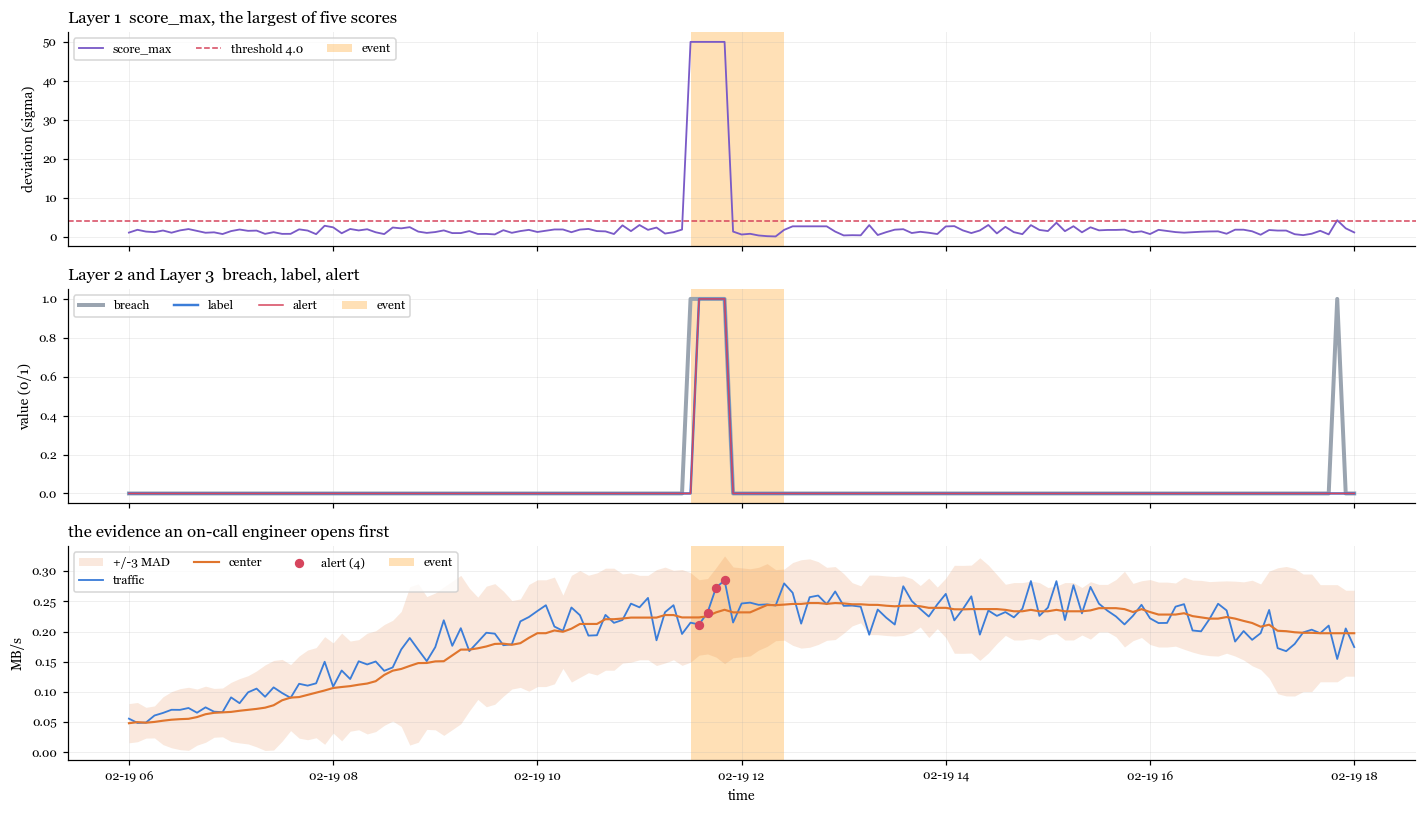

breach without label in this window: 2 samples


In [17]:
look = storm_window()
fig, axes = plt.subplots(3, 1, figsize=(13, 7.5), sharex=True)

axes[0].plot(look["timestamp"], look["score_max"], color="#7A5AC7", lw=1.2, label="score_max")
axes[0].axhline(THRESHOLD, color="#D6455D", ls="--", lw=1.0, label=f"threshold {THRESHOLD}")
axes[0].set_title("Layer 1  score_max, the largest of five scores", loc="left", fontsize=11)
axes[0].set_ylabel("deviation (sigma)", fontsize=9)

for column, color, lw in [("breach", "#9AA4B0", 2.6),
                          ("label", "#3B7DD8", 1.6),
                          ("alert", "#D6455D", 1.0)]:
    axes[1].plot(look["timestamp"], look[column], color=color, lw=lw, label=column)
axes[1].set_title("Layer 2 and Layer 3  breach, label, alert", loc="left", fontsize=11)
axes[1].set_ylabel("value (0/1)")

axes[2].fill_between(look["timestamp"], look["robust_lo"] / 1e6, look["robust_hi"] / 1e6,
                     color="#E0752D", alpha=0.16, lw=0, label="+/-3 MAD")
axes[2].plot(look["timestamp"], look["traffic_bps"] / 1e6,
             color="#3B7DD8", lw=1.2, label="traffic")
axes[2].plot(look["timestamp"], look["robust_center"] / 1e6,
             color="#E0752D", lw=1.4, label="center")
fired = look[look["alert"] > 0]
axes[2].scatter(fired["timestamp"], fired["traffic_bps"] / 1e6,
                s=26, color="#D6455D", zorder=5, label=f"alert ({len(fired)})")
axes[2].set_title("the evidence an on-call engineer opens first", loc="left", fontsize=11)
axes[2].set_xlabel("time")
axes[2].set_ylabel("MB/s", fontsize=9)

for ax in axes:
    shade_truth(ax, look["timestamp"], look["is_incident"])
    ax.legend(fontsize=8, loc="upper left", ncol=4)
    ax.grid(alpha=0.22, lw=0.6)
    for side in ("top", "right"):
        ax.spines[side].set_visible(False)
fig.tight_layout()
plt.show()

dropped = look[(look["breach"] > 0) & (look["label"] == 0)]
print(f"breach without label in this window: {len(dropped)} samples")

### **消融實驗（Ablation Study）:**

* Parameter：`N_CONSEC`（連續確認筆數）、`min_volume`、`gap_tolerance`，都是 `AlertPolicy` 建構時的參數。
* Architecture：`min_volume_col` 決定用哪一欄當流量門檻；換成別的欄位是另一種設計。
* Per-port：`policy` 目前是全體 port 共用同一組物件；第 9 節會看到 `role_weight` 已經是逐 port／逐角色的例外，這裡的其他參數還沒有這樣拆開。

## 4. 評估指標與記分卡（Scorecard）
評估時間序列監控系統時，傳統機器學習的「逐點評估（Point-level metrics）」具備高度誤導性，必須採用「事件層級（Event-level metrics）」指標。

### 指標比較

| 評估維度 | 指標名稱 | 定義與意義 |
| --- | --- | --- |
| **事件層級 (正確)** | **Event Recall** | 成功偵測到的獨立 Incident 時窗比例。核心維運目標。 |
|  | **Alerts per Day** | 每天產生的告警總數。代表維運團隊的負擔上限。 |
|  | **Detection Delay** | 從 Incident 開始到發出第一則告警的時間差（中位數/最大值）。 |
|  | **Duplicate Alerts** | 同一 Incident 被重複拆分成多則告警的平均數量。理想值為 1.0。 |
| **逐點層級 (診斷用)** | **Point Accuracy** | 被極端類別不平衡稀釋。全不告警的系統仍可取得 99.48% Accuracy。 |
|  | **Point Precision** | 逐點精確率。受負樣本基數影響極大。 |
|  | **Precision-Recall (PR)** | 在極端不平衡資料下，PR 曲線遠比 ROC 曲線具備誠實的診斷價值。 |

In [18]:
def point_metrics(labels, truth):
    """Per-sample confusion; kept only to show why point accuracy is the wrong headline.

    At a 0.66% positive rate, a detector that never fires scores point_accuracy
    around 0.9934 -- higher than most real configurations achieve -- which is
    the whole reason event-level recall below is the real scorecard.
    """
    labels = labels.fillna(False).to_numpy(dtype=bool)
    truth = truth.fillna(False).to_numpy(dtype=bool)
    tp, fp = int(np.sum(labels & truth)), int(np.sum(labels & ~truth))
    fn, tn = int(np.sum(~labels & truth)), int(np.sum(~labels & ~truth))
    prec = tp / (tp + fp) if tp + fp else 0.0
    rec = tp / (tp + fn) if tp + fn else 0.0
    f1 = 2 * prec * rec / (prec + rec) if prec + rec else 0.0
    return {"tp": tp, "fp": fp, "fn": fn, "tn": tn, "point_precision": prec,
            "point_recall": rec, "point_f1": f1, "point_accuracy": (tp + tn) / max(tp + tn + fp + fn, 1)}


def match_alerts_to_events(alerts, events, tolerance_s=0.0, unit_col="port_id", notified_only=True):
    """Overlap-match alerts to event windows; returns (events with outcome, alerts with match flag).

    notified_only=True by default: a suppressed alert should not count as a
    detection, since suppression is a deliberate policy choice, not a miss.
    """
    w = alerts.copy()
    if notified_only and "notified" in w.columns:
        w = w[w["notified"]]
    w = w.reset_index(drop=True)
    pad = pd.Timedelta(seconds=tolerance_s)
    rows, matched = [], set()
    for e in events.itertuples():
        hits = w[(w[unit_col] == getattr(e, unit_col)) & (w["fire_time"] <= e.end + pad)
                 & (w["clear_time"] >= e.start - pad)]  # any alert overlapping this event's window, on the same unit
        detected = len(hits) > 0
        matched.update(hits.index.tolist())
        first = hits["fire_time"].min() if detected else pd.NaT  # earliest matching alert sets the detection delay
        rows.append({"event_id": e.event_id, "event_type": e.event_type,
                     unit_col: getattr(e, unit_col), "port_role": getattr(e, "port_role", ""),
                     "start": e.start, "end": e.end, "detected": detected, "n_alerts": int(len(hits)),
                     "first_fire": first,
                     "detection_delay_s": (first - e.start).total_seconds() if detected else np.nan,
                     "peak_score": float(hits["peak_score"].max()) if detected else np.nan})
    w["matched_event"] = w.index.isin(matched)
    cols = ["event_id", "event_type", unit_col, "port_role", "start", "end", "detected",
            "n_alerts", "first_fire", "detection_delay_s", "peak_score"]
    table = pd.DataFrame(rows, columns=None if rows else cols)
    if not rows:
        table = table.astype({"detected": bool, "n_alerts": int})
    return table, w


def evaluate(alerts, events, span, labels=None, truth=None, changes=None, tolerance_s=0.0, method=""):
    """Full operational scorecard: event recall, delay, alert burden, with point metrics as diagnostic.

    event_recall (did we catch the incident) and alerts_per_day (how many
    pages this costs) are the two numbers that actually matter operationally;
    point_accuracy is computed only to show why it should not be trusted here.
    """
    ev, al = match_alerts_to_events(alerts, events, tolerance_s=tolerance_s)
    n_supp = int((~alerts["notified"]).sum()) if "notified" in alerts.columns else 0
    n_ev = len(ev)
    n_det = int(ev["detected"].sum()) if n_ev else 0
    delays = ev.loc[ev["detected"], "detection_delay_s"].dropna()
    n_al = len(al)
    n_true = int(al["matched_event"].sum()) if n_al else 0
    false = al[~al["matched_event"]] if n_al else al
    n_false_change = 0
    if changes is not None and len(changes) and len(false):
        for a in false.itertuples():
            for ch in changes.itertuples():
                if scope_matches(ch.scope, getattr(a, "device_id", ""), getattr(a, "port_id", "")) \
                        and a.fire_time <= ch.end and a.clear_time >= ch.start:  # a false alert landing inside a declared change is a policy gap, not a random false alarm
                    n_false_change += 1
                    break
    days = max((span[1] - span[0]).total_seconds() / 86400.0, 1e-9)
    dup = ev.loc[ev["detected"], "n_alerts"]
    summary = {"method": method, "events_total": n_ev, "events_detected": n_det,
               "event_recall": n_det / n_ev if n_ev else 0.0, "alerts_total": n_al,
               "alerts_suppressed_by_policy": n_supp, "alerts_matching_event": n_true,
               "event_precision": n_true / n_al if n_al else 0.0, "false_alerts": n_al - n_true,
               "false_alerts_on_planned_change": n_false_change,
               "false_alerts_unexplained": (n_al - n_true) - n_false_change,
               "alerts_per_day": n_al / days,
               "median_detection_delay_min": float(delays.median() / 60) if len(delays) else np.nan,
               "max_detection_delay_min": float(delays.max() / 60) if len(delays) else np.nan,
               "duplicate_alerts_per_event": float(dup.mean()) if len(dup) else 0.0,
               "median_alert_duration_min": float(al["duration_s"].median() / 60) if n_al else np.nan}
    if labels is not None and truth is not None:
        summary.update(point_metrics(labels, truth))
    return summary, ev, al

truth = allp["is_incident"].astype(bool)
summary, ev, al = evaluate(alerts, incidents, SPAN, labels=flags["label"], truth=truth,
                           changes=calendar, method="multi_feature")

rate = float(allp["is_incident"].mean())
print(f"event recall            {summary['event_recall']:.4f}"
      f"   ({summary['events_detected']} / {summary['events_total']} 個事件時窗)")
print(f"alerts per day          {summary['alerts_per_day']:.2f}"
      f"   (整月 {summary['alerts_total']}，被變更行事曆壓下 {summary['alerts_suppressed_by_policy']})")
print(f"detection delay median  {summary['median_detection_delay_min']:.0f} min"
      f"   (最慢 {summary['max_detection_delay_min']:.0f} min)")
print(f"duplicates per event    {summary['duplicate_alerts_per_event']:.2f}")
print(f"unexplained false       {summary['false_alerts_unexplained']}")
print()
print(f"point accuracy          {summary['point_accuracy']:.4f}"
      f"   <- 一個永不開口的偵測器可以拿到 {1 - rate:.4f}")

show = ev[["event_id", "event_type", "port_id", "detected", "detection_delay_s", "peak_score"]].copy()
show["delay_min"] = show.pop("detection_delay_s") / 60
missed = ev[~ev["detected"]]
print()
print("missed:", ", ".join(f"{r.event_id} {r.event_type} on {r.port_id}"
                           for r in missed.itertuples()) or "none")

event recall            0.9375   (15 / 16 個事件時窗)
alerts per day          6.07   (整月 182，被變更行事曆壓下 2)
detection delay median  5 min   (最慢 5 min)
duplicates per event    1.07
unexplained false       166

point accuracy          0.9891   <- 一個永不開口的偵測器可以拿到 0.9948

missed: E link_quality_issue on port-id7429


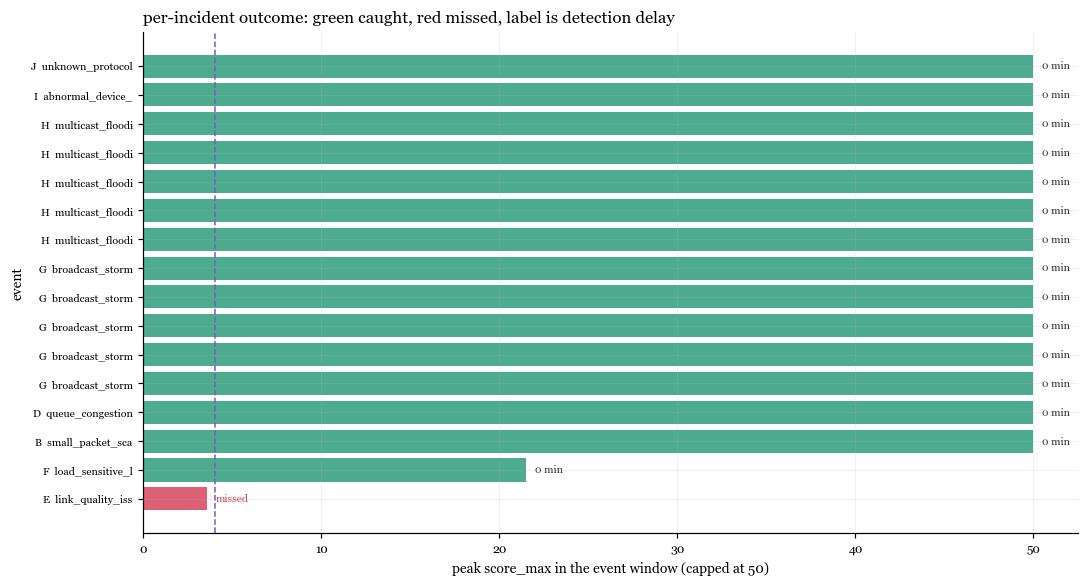

detected 15 / 16 incidents at threshold 4.0


In [19]:
rows = []
for e in incidents.itertuples():
    win = allp[(allp.port_id == e.port_id)
               & (allp.timestamp >= e.start) & (allp.timestamp <= e.end)]
    over = win[win.score_max > THRESHOLD]
    detected = len(over) > 0
    delay = (over.timestamp.min() - e.start).total_seconds() / 60 if detected else np.nan
    rows.append({"event": f"{e.event_id}  {e.event_type[:16]}", "detected": detected,
                 "delay_min": delay, "peak": float(win.score_max.max())})
det = pd.DataFrame(rows).sort_values(["detected", "peak"]).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(10, max(3.2, 0.34 * len(det))))
ypos = np.arange(len(det))
ax.barh(ypos, det.peak.clip(upper=50),
        color=[PALETTE["peer"] if d else PALETTE["alert"] for d in det.detected], alpha=0.85)
ax.axvline(THRESHOLD, color=PALETTE["score"], ls="--", lw=1.0)
for yp, r in zip(ypos, det.itertuples()):
    tag = f"{r.delay_min:.0f} min" if r.detected else "missed"
    ax.text(min(r.peak, 50) + 0.5, yp, tag, va="center", fontsize=7,
            color="#333333" if r.detected else PALETTE["alert"])
ax.set_yticks(ypos); ax.set_yticklabels(det.event, fontsize=7)
ax.set_xlabel("peak score_max in the event window (capped at 50)")
ax.set_ylabel("event")
ax.set_title("per-incident outcome: green caught, red missed, label is detection delay")
fig.tight_layout()
plt.show()

print(f"detected {int(det.detected.sum())} / {len(det)} incidents at threshold {THRESHOLD}")

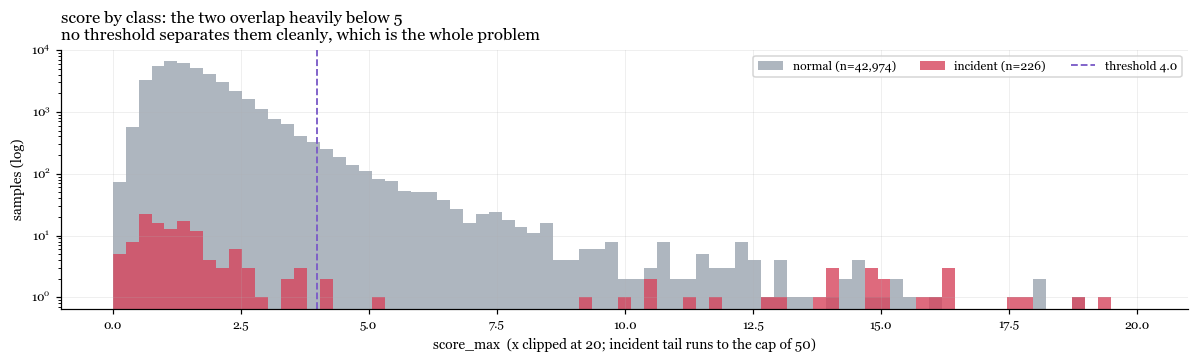

positive (incident) base rate: 0.5231%


In [20]:
# score_max split by ground truth: if this overlap were small, a single
# threshold would separate incidents from normal traffic cleanly. It is not
# small, which is the entire reason confirmation and policy layers exist on
# top of the raw score.
y = allp["is_incident"].astype(bool).to_numpy()
s = allp["score_max"].to_numpy()
base_rate = y.mean()

fig, ax = plt.subplots(figsize=(11, 3.4))
bins = np.linspace(0, 20, 80)
ax.hist(s[~y], bins=bins, color=PALETTE["muted"], alpha=0.8,
        label=f"normal (n={np.sum(~y):,})", log=True)
ax.hist(s[y], bins=bins, color=PALETTE["alert"], alpha=0.8,
        label=f"incident (n={np.sum(y):,})", log=True)
ax.axvline(THRESHOLD, color=PALETTE["score"], ls="--", lw=1.2, label=f"threshold {THRESHOLD}")
ax.set_xlabel("score_max  (x clipped at 20; incident tail runs to the cap of 50)")
ax.set_ylabel("samples (log)")
ax.set_title("score by class: the two overlap heavily below 5\n"
             "no threshold separates them cleanly, which is the whole problem")
ax.legend(loc="upper right", ncol=3)
fig.tight_layout()
plt.show()

print(f"positive (incident) base rate: {base_rate:.4%}")

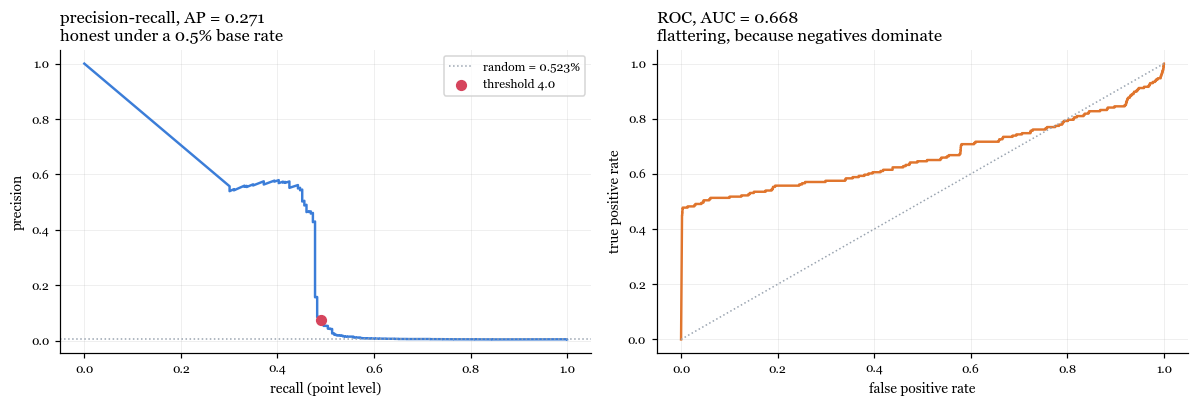

In [21]:
# Point-level PR and ROC on score_max. Kept as a diagnostic, not the
# headline metric: ROC looks flattering here specifically because normal
# samples vastly outnumber incident ones, which is what Part K argues against
# trusting.
from sklearn.metrics import (precision_recall_curve, average_precision_score,
                             roc_curve, roc_auc_score)

prec, rec, thr = precision_recall_curve(y, s)
ap = average_precision_score(y, s)
fpr, tpr, _ = roc_curve(y, s)
auc = roc_auc_score(y, s)

fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
axes[0].plot(rec, prec, color=PALETTE["signal"], lw=1.6)
axes[0].axhline(base_rate, color=PALETTE["muted"], ls=":", lw=1.0,
                label=f"random = {base_rate:.3%}")
k = int(np.searchsorted(thr, THRESHOLD))
if k < len(prec):
    axes[0].scatter([rec[k]], [prec[k]], s=40, color=PALETTE["alert"], zorder=5,
                    label=f"threshold {THRESHOLD}")
axes[0].set_xlabel("recall (point level)")
axes[0].set_ylabel("precision")
axes[0].set_title(f"precision-recall, AP = {ap:.3f}\nhonest under a 0.5% base rate")
axes[0].legend(loc="upper right")

axes[1].plot(fpr, tpr, color=PALETTE["baseline"], lw=1.6)
axes[1].plot([0, 1], [0, 1], color=PALETTE["muted"], ls=":", lw=1.0)
axes[1].set_xlabel("false positive rate")
axes[1].set_ylabel("true positive rate")
axes[1].set_title(f"ROC, AUC = {auc:.3f}\nflattering, because negatives dominate")
fig.tight_layout()
plt.show()

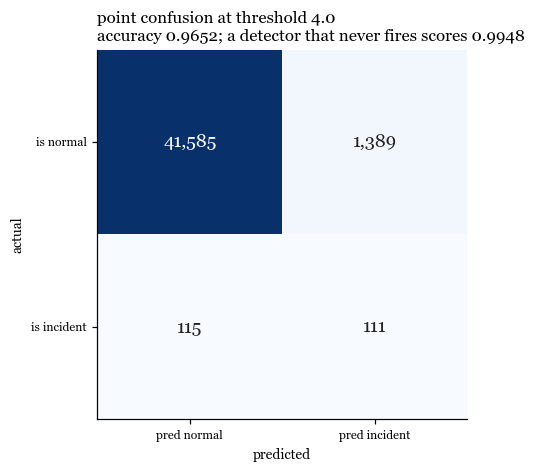

In [22]:
pred = s > THRESHOLD
tp = int(np.sum(pred & y)); fp = int(np.sum(pred & ~y))
fn = int(np.sum(~pred & y)); tn = int(np.sum(~pred & ~y))
cm = np.array([[tn, fp], [fn, tp]])

fig, ax = plt.subplots(figsize=(5.4, 4.4))
ax.imshow(cm, cmap="Blues")
for i in range(2):
    for j in range(2):
        ax.text(j, i, f"{cm[i, j]:,}", ha="center", va="center",
                fontsize=12, color="white" if cm[i, j] > cm.max() * 0.5 else "#222222")
ax.set_xticks([0, 1]); ax.set_xticklabels(["pred normal", "pred incident"])
ax.set_yticks([0, 1]); ax.set_yticklabels(["is normal", "is incident"])
ax.set_xlabel("predicted")
ax.set_ylabel("actual")
acc = (tp + tn) / cm.sum()
ax.set_title(f"point confusion at threshold {THRESHOLD}\n"
             f"accuracy {acc:.4f}; a detector that never fires scores {1 - base_rate:.4f}")
ax.grid(False)
fig.tight_layout()
plt.show()

## 5. 第 8 步：在這條線上，自己選一個立足點
營運決策實質上是在事件召回率（Event Recall）**與**每日告警負擔（Alerts per Day）之間尋找平衡點，這條線上沒有一個點是「正確答案」，只有取捨。出廠設定（Threshold $=4.0$, $n=2$）在 42 種組合中，於 $R=10/100/1000$ 三個代價比率下的排名分別是第 31、24、27 名，從來沒有贏過，因為這個成本函數完全沒有替延遲標價，讓 $n$ 可以無限拉高換安靜。這一步要做的不是找出「最佳」設定，是把取捨攤開，自己選一個立足點。

### 雙參數格點搜尋 (Threshold $\times$ $n\_consecutive$)

透過 $7 \times 6$ 網格分析可歸納出以下特性：

1. **Recall 高原現象：** 在多數參數組合中，Event Recall 會維持在固定高原（例如 0.9375）。然而在此高原區間內，每日告警數可能相差數十倍（如 0.67 則/天 vs 32.67 則/天）。
2. **延遲與確認筆數解耦：** 偵測延遲完全由 $n\_consecutive$ 決定，與閾值大小無關。

### 成本函數導向之最佳化

定義總營運成本函數：

$$\text{Cost} = (\text{Missed Events}) \times R + (\text{Alerts Total})$$

其中 $R = \frac{C_{\text{miss}}}{C_{\text{alert}}}$ 代表「漏報一次事故代價」對比「處理一則告警成本」的比率：

* **$R < 1.5$：** 漏報成本極低，最佳解趨向高閾值與長 confirmation（如 Threshold $=4.0, n=6$），Recall 顯著下降。
* **$1.5 \le R < 130$：** 最佳解落在 Threshold $=5.0, n=5$，以極低告警數維持高 Recall。
* **$R \ge 130$：** 事故代價極高，最佳解切換至 Threshold $=2.5, n=4$，犧牲安靜度以換取 100% 召回。

若進一步考慮延遲成本（每分鐘延遲計費 $C_{\text{delay}}$），較小 confirmation 筆數（如 $n=2$）的價值才會重新顯現。

packets_pps  min 3.37  1st pct 6.17  median 64.92
samples the shipped gate (min_volume=1.0) excludes: 0


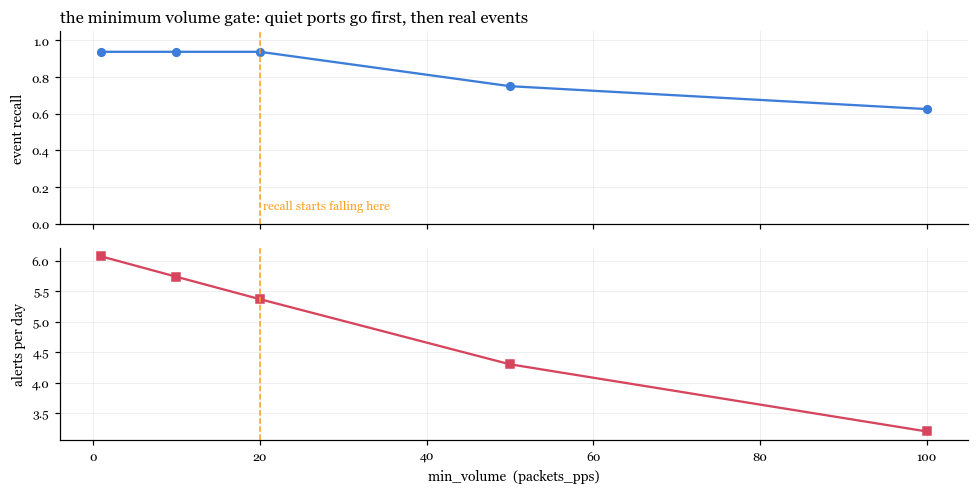

merging label runs across a gap
 gap_tolerance  alerts  duplicates_per_event  event_recall
             0     182                  1.07        0.9375
             1     182                  1.07        0.9375
             2     178                  1.00        0.9375
             3     174                  1.00        0.9375
             5     171                  1.00        0.9375


In [23]:
# Two knobs from Part J's policy, swept independently: min_volume trades
# recall for quiet on low-traffic ports, gap_tolerance merges label runs
# across a brief drop-out. The shipped defaults are checked against both
# sweeps rather than assumed correct.
def scorecard(min_volume=1.0, gap_tolerance=1, critical_score=2.0):
    pol = AlertPolicy(min_consecutive=N_CONSEC, gap_tolerance=gap_tolerance,
                         min_volume_col="packets_pps", min_volume=min_volume,
                         critical_score=critical_score)
    made = build_alerts(allp, "label", "score_max", policy=pol, cadence_s=CADENCE,
                           changes=calendar, method="multi_feature")
    got, _, _ = evaluate(made, incidents, SPAN, labels=flags["label"], truth=truth,
                         changes=calendar)
    return made, got


print(f"packets_pps  min {allp['packets_pps'].min():.2f}  "
      f"1st pct {allp['packets_pps'].quantile(0.01):.2f}  "
      f"median {allp['packets_pps'].median():.2f}")
print(f"samples the shipped gate (min_volume={policy.min_volume}) excludes: "
      f"{int((allp['packets_pps'] < policy.min_volume).sum())}")

rows = []
for mv in [1, 10, 20, 50, 100]:
    _, got = scorecard(min_volume=float(mv))
    rows.append({"min_volume": mv, "per_day": got["alerts_per_day"],
                 "event_recall": got["event_recall"]})
knob = pd.DataFrame(rows)

fig, axes = plt.subplots(2, 1, figsize=(9, 4.6), sharex=True)
axes[0].plot(knob["min_volume"], knob["event_recall"], marker="o", ms=5,
             color=PALETTE["signal"])
axes[0].set_ylabel("event recall")
axes[0].set_ylim(0, 1.05)
axes[0].set_title("the minimum volume gate: quiet ports go first, then real events")
axes[1].plot(knob["min_volume"], knob["per_day"], marker="s", ms=5, color=PALETTE["alert"])
axes[1].set_ylabel("alerts per day")
axes[1].set_xlabel("min_volume  (packets_pps)")
for ax in axes:
    ax.axvline(20, color=PALETTE["truth"], ls="--", lw=1.0)
axes[0].text(20, 0.08, " recall starts falling here", fontsize=8, color=PALETTE["truth"])
fig.tight_layout()
plt.show()

rows = []
for gt in [0, 1, 2, 3, 5]:
    _, got = scorecard(gap_tolerance=gt)
    rows.append({"gap_tolerance": gt, "alerts": got["alerts_total"],
                 "duplicates_per_event": round(got["duplicate_alerts_per_event"], 2),
                 "event_recall": round(got["event_recall"], 4)})
print("merging label runs across a gap")
print(pd.DataFrame(rows).to_string(index=False))

In [24]:
def sweep(frame, score_col, events, span, thresholds, build_alerts_fn,
          truth=None, direction="high", n_consecutive=3):
    """Trace the operating curve as the threshold moves: recall and delay against alerts per day.

    Each threshold is a full confirm -> build_alerts -> evaluate pass, not an
    approximation, so the resulting curve reflects the actual policy, not a
    theoretical one.
    """
    rows = []
    for t in thresholds:
        flags = confirm(frame[score_col], t, n_consecutive, direction=direction)
        alerts = build_alerts_fn(frame.assign(_label=flags["label"]), "_label", score_col)
        summary, _, _ = evaluate(alerts, events, span,
                                 labels=flags["label"] if truth is not None else None, truth=truth)
        summary["threshold"] = t
        summary["n_consecutive"] = n_consecutive
        rows.append(summary)
    return pd.DataFrame(rows)

def make_alerts(frame, label_col, score_col):
    return build_alerts(frame, label_col, score_col, policy=policy,
                           cadence_s=CADENCE, changes=calendar, method="sweep")

curve = sweep(allp, "score_max", incidents, SPAN,
                 thresholds=[2.5, 3.0, 3.5, 4.0, 4.5, 5.0, 6.0, 8.0],
                 build_alerts_fn=make_alerts, truth=truth, n_consecutive=N_CONSEC)

print(curve[["threshold", "events_detected", "event_recall", "alerts_total", "alerts_per_day",
             "median_detection_delay_min", "false_alerts", "point_accuracy"]]
      .round(3).to_string(index=False))

 threshold  events_detected  event_recall  alerts_total  alerts_per_day  median_detection_delay_min  false_alerts  point_accuracy
       2.5               16         1.000          1065          35.504                         5.0          1048           0.958
       3.0               16         1.000           511          17.035                         5.0           494           0.978
       3.5               15         0.938           291           9.701                         5.0           275           0.986
       4.0               15         0.938           182           6.067                         5.0           166           0.989
       4.5               15         0.938           133           4.434                         5.0           118           0.991
       5.0               15         0.938            94           3.134                         5.0            79           0.992
       6.0               15         0.938            58           1.934                   

grid 42 configurations
recall 0.9375 plateau: 28 of 42 cells, alerts/day 0.67 to 32.67 (49x)
shipped (4.0, 2) cost rank at R = 10 / 100 / 1000: 31 of 42 / 24 of 42 / 27 of 42

optimum as the cost ratio moves
    R  threshold  n_consecutive  event_recall  alerts_per_day  delay_min
    1          4              6          0.25        0.133349         25
  1.5          5              5        0.9375        0.666744         20
130.4        2.5              4             1          4.9339         15


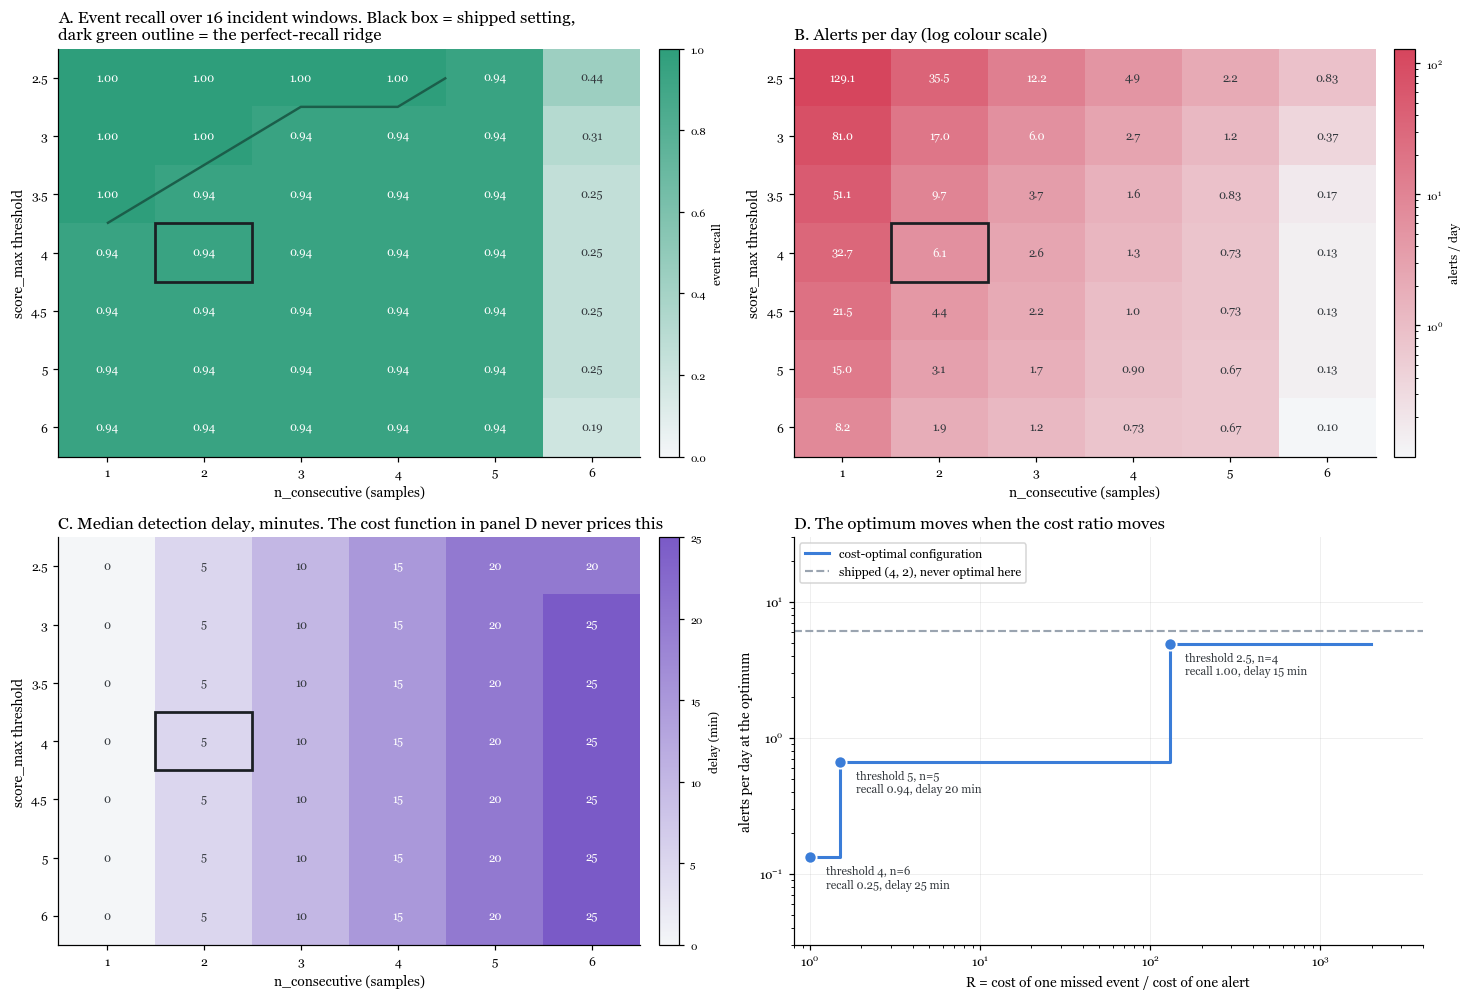

adding a delay term at R = 100
  C_delay  0.0  ->  threshold 5, n_consecutive 5, recall 0.9375, alerts/day 0.67, delay 20 min
  C_delay  0.1  ->  threshold 6, n_consecutive 4, recall 0.9375, alerts/day 0.73, delay 15 min
  C_delay 0.25  ->  threshold 6, n_consecutive 3, recall 0.9375, alerts/day 1.20, delay 10 min
  C_delay  0.5  ->  threshold 6, n_consecutive 2, recall 0.9375, alerts/day 1.93, delay 5 min
  C_delay  1.0  ->  threshold 6, n_consecutive 2, recall 0.9375, alerts/day 1.93, delay 5 min


In [25]:
# ---------------------------------------------------------------------------
# Joint tuning grid: threshold x n_consecutive, then an explicit cost function.
# 42 configurations, each one a full confirm -> build_alerts -> evaluate pass.
# ---------------------------------------------------------------------------
from matplotlib.colors import LinearSegmentedColormap, LogNorm, Normalize
from matplotlib.patches import Rectangle

T_GRID = [2.5, 3.0, 3.5, 4.0, 4.5, 5.0, 6.0]
C_GRID = [1, 2, 3, 4, 5, 6]

jrows = []
for t in T_GRID:
    for n in C_GRID:
        f = confirm(allp["score_max"], t, n_consecutive=n, direction="high")
        a = make_alerts(allp.assign(_label=f["label"]), "_label", "score_max")
        s, _, _ = evaluate(a, incidents, SPAN, labels=f["label"], truth=truth)
        jrows.append({"threshold": t, "n_consecutive": n,
                      "event_recall": s["event_recall"],
                      "missed": s["events_total"] - s["events_detected"],
                      "alerts_total": s["alerts_total"],
                      "alerts_per_day": s["alerts_per_day"],
                      "delay_min": s["median_detection_delay_min"]})
jgrid = pd.DataFrame(jrows)

# Cost over the evaluation month, in units of one alert triage (C_alert = 1).
# R = C_miss / C_alert: how many triages one missed event is worth to the business.
R_GRID = np.unique(np.round(np.logspace(0, 3.3, 40), 1))
opt_rows = []
for r in R_GRID:
    c = jgrid["missed"] * r + jgrid["alerts_total"]
    g = jgrid.loc[int(c.idxmin())]
    opt_rows.append({"R": r, "threshold": g.threshold, "n_consecutive": int(g.n_consecutive),
                     "event_recall": g.event_recall, "alerts_per_day": g.alerts_per_day,
                     "delay_min": g.delay_min})
opt_path = pd.DataFrame(opt_rows)

ship = jgrid[(jgrid.threshold == THRESHOLD) & (jgrid.n_consecutive == N_CONSEC)].iloc[0]
plateau = jgrid[jgrid.event_recall == ship.event_recall]
ship_rank = [int((jgrid["missed"] * r + jgrid["alerts_total"]
                  < ship.missed * r + ship.alerts_total).sum()) + 1 for r in (10, 100, 1000)]

print(f"grid {len(jgrid)} configurations")
print(f"recall {ship.event_recall:.4f} plateau: {len(plateau)} of {len(jgrid)} cells, "
      f"alerts/day {plateau.alerts_per_day.min():.2f} to {plateau.alerts_per_day.max():.2f} "
      f"({plateau.alerts_per_day.max() / plateau.alerts_per_day.min():.0f}x)")
print(f"shipped ({THRESHOLD}, {N_CONSEC}) cost rank at R = 10 / 100 / 1000: "
      + " / ".join(f"{k} of {len(jgrid)}" for k in ship_rank))
print()
print("optimum as the cost ratio moves")
print(opt_path.drop_duplicates(subset=["threshold", "n_consecutive"])
      .to_string(index=False, float_format=lambda v: f"{v:g}"))


def ramp(hue):
    return LinearSegmentedColormap.from_list("r", ["#F4F6F8", hue])


def heat(ax, column, cmap, norm, fmt, title, cbar_label, outline_at=None):
    m = jgrid.pivot(index="threshold", columns="n_consecutive", values=column)
    im = ax.imshow(m.to_numpy(), cmap=cmap, norm=norm, aspect="auto", origin="upper")
    ax.set_xticks(range(len(C_GRID)), [str(c) for c in C_GRID])
    ax.set_yticks(range(len(T_GRID)), [f"{t:g}" for t in T_GRID])
    ax.set_xlabel("n_consecutive (samples)")
    ax.set_ylabel("score_max threshold")
    ax.set_title(title)
    ax.grid(False)
    for i, t in enumerate(T_GRID):
        for j, n in enumerate(C_GRID):
            v = m.loc[t, n]
            dark = norm(v) > 0.55
            ax.text(j, i, fmt(v), ha="center", va="center", fontsize=7.5,
                    color="#FFFFFF" if dark else "#33383D")
    if outline_at is not None:
        ax.contour(np.isclose(m.to_numpy(), outline_at).astype(float), levels=[0.5],
                   colors="#1B5E4A", linewidths=1.6)
    ax.add_patch(Rectangle((C_GRID.index(N_CONSEC) - 0.5, T_GRID.index(THRESHOLD) - 0.5), 1, 1,
                           fill=False, edgecolor="#1B1F23", linewidth=1.8))
    cb = fig.colorbar(im, ax=ax, fraction=0.045, pad=0.03)
    cb.set_label(cbar_label, fontsize=8)
    cb.ax.tick_params(labelsize=7)


fig, axes = plt.subplots(2, 2, figsize=(13.5, 9.2))
fig.subplots_adjust(hspace=0.32, wspace=0.28)

heat(axes[0, 0], "event_recall", ramp(PALETTE["peer"]), Normalize(0, 1), lambda v: f"{v:.2f}",
     "A. Event recall over 16 incident windows. Black box = shipped setting,\n"
     "dark green outline = the perfect-recall ridge", "event recall", outline_at=1.0)
heat(axes[0, 1], "alerts_per_day", ramp(PALETTE["alert"]),
     LogNorm(jgrid.alerts_per_day.min(), jgrid.alerts_per_day.max()),
     lambda v: f"{v:.1f}" if v >= 1 else f"{v:.2f}",
     "B. Alerts per day (log colour scale)", "alerts / day")
heat(axes[1, 0], "delay_min", ramp(PALETTE["score"]), Normalize(0, 25), lambda v: f"{v:.0f}",
     "C. Median detection delay, minutes. The cost function in panel D never prices this",
     "delay (min)")

ax = axes[1, 1]
ax.step(opt_path["R"], opt_path["alerts_per_day"], where="post",
        color=PALETTE["signal"], linewidth=2.0, label="cost-optimal configuration")
ax.axhline(ship.alerts_per_day, color=PALETTE["muted"], linewidth=1.4, linestyle="--",
           label=f"shipped ({THRESHOLD:g}, {N_CONSEC}), never optimal here")
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("R = cost of one missed event / cost of one alert")
ax.set_ylabel("alerts per day at the optimum")
ax.set_title("D. The optimum moves when the cost ratio moves")
seen = set()
for row in opt_path.itertuples():
    key = (row.threshold, row.n_consecutive)
    if key in seen:
        continue
    seen.add(key)
    ax.plot(row.R, row.alerts_per_day, "o", color=PALETTE["signal"], markersize=8,
            markeredgecolor="#FFFFFF", markeredgewidth=1.2, zorder=3)
    ax.annotate(f"threshold {row.threshold:g}, n={row.n_consecutive}\n"
                f"recall {row.event_recall:.2f}, delay {row.delay_min:.0f} min",
                (row.R, row.alerts_per_day), textcoords="offset points", xytext=(10, -20),
                fontsize=7.5, color="#33383D")
ax.set_xlim(0.8, 4000)
ax.set_ylim(0.03, 30)
ax.legend(loc="upper left")

fig.tight_layout()
plt.show()

# What would have to be priced for the shipped n_consecutive to come back?
# Same two-term cost at R = 100, plus C_delay per minute of median delay per detected event.
print("adding a delay term at R = 100")
for cd in [0.0, 0.1, 0.25, 0.5, 1.0]:
    c = (jgrid["missed"] * 100 + jgrid["alerts_total"]
         + (len(incidents) - jgrid["missed"]) * jgrid["delay_min"] * cd)
    g = jgrid.loc[int(c.idxmin())]
    print(f"  C_delay {cd:>4}  ->  threshold {g.threshold:g}, n_consecutive {int(g.n_consecutive)}, "
          f"recall {g.event_recall:.4f}, alerts/day {g.alerts_per_day:.2f}, delay {g.delay_min:.0f} min")

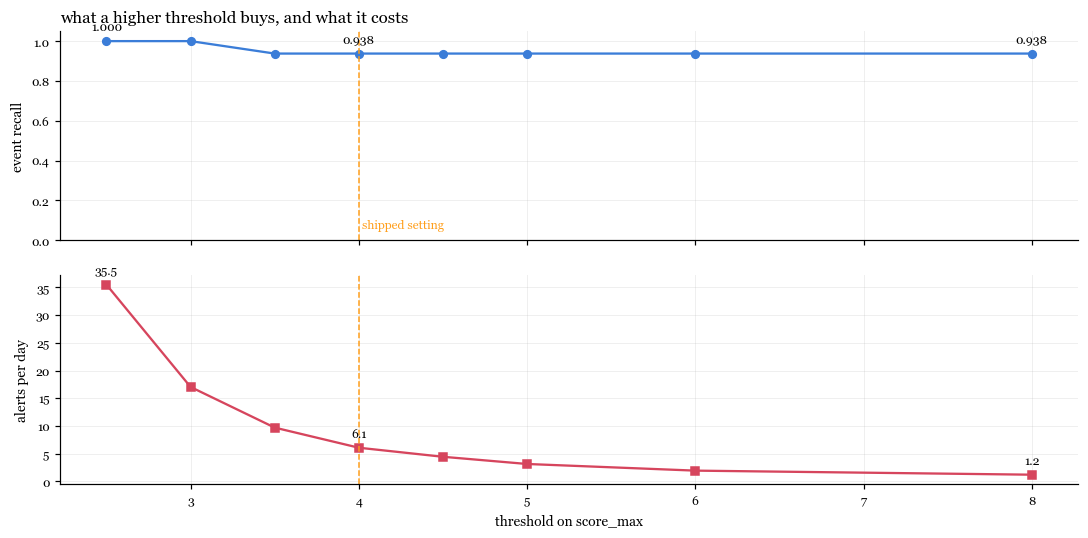

In [26]:
# 兩個量的尺度不同，所以分成上下兩格共用一條 x 軸，而不是把第二個量掛到右軸。
# 雙軸圖會讓兩條線的交叉點看起來有意義，但那個交叉點只是兩個刻度湊出來的。
fig, axes = plt.subplots(2, 1, figsize=(10, 5.0), sharex=True)

axes[0].plot(curve["threshold"], curve["event_recall"], marker="o", ms=5,
             color=PALETTE["signal"])
axes[0].set_ylabel("event recall")
axes[0].set_ylim(0, 1.05)
axes[0].set_title("what a higher threshold buys, and what it costs")
for x, y in zip(curve["threshold"], curve["event_recall"]):
    if x in (curve["threshold"].min(), THRESHOLD, curve["threshold"].max()):
        axes[0].annotate(f"{y:.3f}", (x, y), textcoords="offset points",
                         xytext=(0, 7), ha="center", fontsize=8)

axes[1].plot(curve["threshold"], curve["alerts_per_day"], marker="s", ms=5,
             color=PALETTE["alert"])
axes[1].set_ylabel("alerts per day")
axes[1].set_xlabel("threshold on score_max")
for x, y in zip(curve["threshold"], curve["alerts_per_day"]):
    if x in (curve["threshold"].min(), THRESHOLD, curve["threshold"].max()):
        axes[1].annotate(f"{y:.1f}", (x, y), textcoords="offset points",
                         xytext=(0, 7), ha="center", fontsize=8)

for ax in axes:
    ax.axvline(THRESHOLD, color=PALETTE["truth"], ls="--", lw=1.0)
axes[0].text(THRESHOLD, 0.06, " shipped setting", fontsize=8, color=PALETTE["truth"])

fig.tight_layout()
plt.show()

### **消融實驗（Ablation Study）:**

* Parameter：`T_GRID`／`C_GRID`（掃描範圍）、成本函數裡的 `R` 與 `C_delay`，全部是可以重新設定的輸入。
* Architecture：成本函數本身的形式（`missed × R + alerts`）是一個設計選擇，換一種函數形狀會選出不同的格子。
* Per-port：整張網格是全體資料算出來的單一組設定；不同資產角色（`role_weight`，第 9 節）值得有各自的操作點，這裡還沒拆開。

## 6. 現有告警規則解析 (PromQL)

第 8 步選定的立足點，從這裡開始變成一個要交付、要能撐住的系統：怎麼接上現有的告警規則、怎麼在維護時窗裡保持安靜、嚴重度怎麼分級、通知裡要放什麼、閾值誰簽字、標記不完整時怎麼辦、以及怎麼證明它在沒看過的資料上依然成立。以下到第 15 節都是這個收尾，不是新的判斷步驟。

以 Prometheus / Grafana 生態系中的 `TrafficAnomaly` 規則為例：

```yaml
- alert: TrafficAnomaly
  expr: abs(aiops_traffic_score) > 3
  for: 1m
  labels:
    severity: warning
    source: detector
```

結構映射：

* `aiops_traffic_score`：Layer 1 的連續 Z-score 分數（由 Python `detector.py` 計算後寫回）。
* `> 3`：Layer 2 的門檻觸發條件（Breach Threshold）。
* `for: 1m`：Layer 2 的連續時間確認（等同於 Prometheus 取樣率下的 Confirmation Period）。

**架構分離點：** PromQL 無法原生計算兩層巢狀中位數（MAD），因此複雜的非參數統計 Baseline 留在 Python 端執行，運算結果轉為標準 Metric 送回 Prometheus；告警觸發與生命週期管理則保留在 PromQL / Alertmanager。

## 7. 規則設計要素

建立自訂告警規則（如 `Small Packet Flood`）時，必須明確定義以下六個要素：

1. **Rule Name：** 具體反映異常行為的名稱（如 `SmallPacketFlood`）。
2. **Query：** 底層 Metric 查詢（如以 `net:avg_pkt_bytes` 與 `net:packets_pps` 組合）。
3. **Reducer / Evaluator：** 選用 `last`（即時值）或 `min`（區間最小值）。
4. **Threshold Direction & Value：** 判定方向（如 `IS BELOW 200`）與臨界值。
5. **Evaluation Interval & Pending Period (`for`)：** 評估頻率與轉為 Firing 前需維持的 Pending 時間。
6. **Labels & Annotations：** 包含 `severity` 標籤，以及包含動態變數（如 `{{ $labels.device }}` 與 `{{ $values.B }}`）的 Context 說明。

### **消融實驗（Ablation Study）:** 這六項本身就是這一節要決定的東西，不是額外的旋鈕：

* Parameter：Threshold 的值、Evaluation Interval、Pending Period。
* Architecture：Reducer（`last` 或 `min`）決定的是不同的偵測邏輯，Query 決定看哪個 metric。
* Per-port：Grafana 規則預設套用到所有回傳 query 的 series（也就是所有 port）；要逐 port 給不同閾值需要另外拆規則或用 template variable。

## 8. 維護時窗與發送端壓制

維護時窗（Grafana Mute Timing / Alertmanager Silence）與偵測端壓制具備不同的系統語意：

* **偵測端壓制 (Detector-side Suppression)：** 候選告警在模型內部即被標記 `suppressed_by`，不生成通知記錄。
* **發送端壓制 (Notification-side Muting)：** 告警規則照常評估並進入 Firing 狀態，在 Alerting UI 可見，僅在派發至 Contact Point 時被靜音。

**維運規範：** Mute Timing 的時間區間必須嚴格根據變更單（Change Calendar）登記的起訖時間設定，並預留指令執行與流量上升的 buffer 時間（如提前 10 分鐘）。

### **消融實驗（Ablation Study）:**

* Parameter：維護時窗的起訖時間與 buffer（例如提前 10 分鐘）。
* Architecture：偵測端壓制（`suppressed_by`）跟發送端壓制（Mute Timing）是兩個獨立機制，選哪一層做壓制是設計決定。


## 9. 嚴重度動態評級模型
告警嚴重度（Severity）不應硬編碼，而應由偏離度、持續時間與資產重要性共同決定：

$$\text{Severity Score} = 0.5 \times \min\left(\frac{\text{Peak Score}}{\text{Critical Score}}, 2\right) + 0.3 \times \min\left(\frac{\text{Duration}}{\text{Critical Duration}}, 2\right) + 0.4 \times \text{Role Weight}$$

* **臨界值設計缺陷：** 若告警門檻設為 $4.0$，而分數公式中的 `Critical Score` 預設過低（如 $2.0$），則所有通過門檻的告警在偏離度項皆直接填滿（$\ge 2.0$），導致所有告警全部被歸類為 `Critical`，使分級機制失真。
* **修正方式：** 將 `Critical Score` 調高至顯著高於告警門檻的數值（如 $12.0 \sim 15.0$），確保不同強度的偏離能拉開階梯差距。

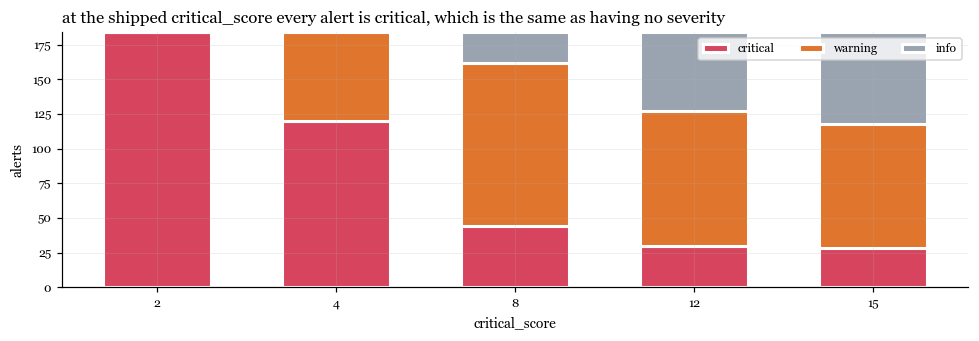

In [27]:
# Same scorecard function as the min_volume/gap_tolerance sweep, this time
# varying critical_score. At the shipped value, every alert that clears the
# door is already classified critical, which is the severity-model bug
# described above made visible.
rows = []
for cs in [2.0, 4.0, 8.0, 12.0, 15.0]:
    made, _ = scorecard(critical_score=cs)
    counts = made["severity"].value_counts()
    rows.append({"critical_score": cs,
                 "critical": int(counts.get("critical", 0)),
                 "warning": int(counts.get("warning", 0)),
                 "info": int(counts.get("info", 0))})
sev = pd.DataFrame(rows)

fig, ax = plt.subplots(figsize=(9, 3.2))
x = np.arange(len(sev))
bottom = np.zeros(len(sev))
for name, colour in [("critical", PALETTE["alert"]),
                     ("warning", PALETTE["baseline"]),
                     ("info", PALETTE["muted"])]:
    ax.bar(x, sev[name], bottom=bottom, width=0.6, label=name,
           color=colour, edgecolor="white", linewidth=2)
    bottom += sev[name].to_numpy()
ax.set_xticks(x)
ax.set_xticklabels([f"{v:g}" for v in sev["critical_score"]])
ax.set_xlabel("critical_score")
ax.set_ylabel("alerts")
ax.set_title("at the shipped critical_score every alert is critical, "
             "which is the same as having no severity")
ax.legend(loc="upper right", ncol=3)
fig.tight_layout()
plt.show()

### **消融實驗（Ablation Study）:**

* Parameter：`critical_score`、`critical_duration_s`，公式裡兩個門檻常數。
* Architecture：嚴重度公式本身的加權（0.5／0.3／0.4）是一個設計決定，換一組權重會改變分級的鬆緊。
* Per-port：`DEFAULT_ROLE_WEIGHT` 已經是逐 port 角色（`wan-primary`、`backup-storage`⋯）給不同權重，是這整份教材裡最完整的逐 port 例子。
* Adaptive：目前 `role_weight` 是工作坊寫死的預設值；正式環境應該由營運方定期覆核調整，而不是一次設定不變。

## 10. 可行動告警（Actionable Notification）結構
一則具備完全上下文、無須維運人員手動重建資訊的告警通知，必須包含以下關鍵欄位：

```text
[CRITICAL] score_max over traffic_bps on port-id7431 (backup-storage)
  detector         multi_feature vs 1h rolling median/MAD, threshold 4.0, 2 consecutive samples
  current_value    traffic_bps = 420 MB/s (baseline median = 45 MB/s)
  deviation        42.76 (peak at 2026-02-07 13:10:00)
  started          2026-02-07 13:00:00
  duration         180 min over 36 samples
  severity         critical (score 1.25)
  rule_version     v2026.02.01-prod
  dashboard        http://localhost:3000/d/aiops-workshop
  runbook          runbooks/traffic-deviation.md
```

**範本語法區隔：**

* 告警規則 Annotations 內使用 `{{ $values.B }}` 與 `{{ $labels.device }}`（規則求值時展開）。
* Contact Point 範本內使用 `{{ .Annotations.summary }}` 與 `{{ .Labels.device }}`（發送通知時展開）。

In [28]:
def notification_text(alert, metric, baseline_desc, dashboard_url="", runbook=""):
    """The message body an on-call engineer receives, with the context the detector already had.

    A z-score alone does not say whether traffic moved from 200 to 400 Mbps
    or from 2 to 4 Mbps -- current value and baseline value are included so
    nobody has to reconstruct that by hand at 3am.
    """
    lines = [f"[{alert['severity'].upper()}] {metric} on {alert.get('port_id', '?')} ({alert.get('port_role', '?')})",
             f"  detector      {alert['method']}  vs  {baseline_desc}",
             f"  deviation     {alert['peak_score']:.2f} (peak at {alert['peak_time']})",
             f"  started       {alert['fire_time']}",
             f"  duration      {alert['duration_s'] / 60:.0f} min over {alert['n_samples']} samples",
             f"  severity      {alert['severity']} (score {alert['severity_score']})"]
    if alert.get("suppressed_by"):
        lines.append(f"  suppressed    planned change {alert['suppressed_by']}")
    if dashboard_url:
        lines.append(f"  dashboard     {dashboard_url}")
    if runbook:
        lines.append(f"  runbook       {runbook}")
    return "\n".join(lines)

matched = al[al["matched_event"]]
pick = matched.loc[matched["duration_s"].idxmax()]

print(notification_text(
    pick,
    metric="score_max over traffic_bps + shape features",
    baseline_desc=f"1h rolling median/MAD, threshold {THRESHOLD}, {N_CONSEC} consecutive samples",
    dashboard_url="http://localhost:3000/d/aiops-workshop",
    runbook="runbooks/traffic-deviation.md",
))
print()
print("evidence carried on the alert record, per feature:")
print(pick[[c for c in matched.columns if c.startswith("evidence_")]].round(2).to_string())

[CRITICAL] score_max over traffic_bps + shape features on port-id7427 (wan-primary)
  detector      multi_feature  vs  1h rolling median/MAD, threshold 4.0, 2 consecutive samples
  deviation     21.30 (peak at 2026-02-17 17:30:00)
  started       2026-02-17 16:05:00
  duration      105 min over 21 samples
  severity      critical (score 2.0)
  dashboard     http://localhost:3000/d/aiops-workshop
  runbook       runbooks/traffic-deviation.md

evidence carried on the alert record, per feature:
evidence_score_robust        21.3
evidence_score_seasonal     21.15
evidence_score_broadcast     2.28
evidence_score_multicast     1.38
evidence_score_pktsize      17.77


## 11. 閾值決策與生命週期
告警閾值並非純粹的數學問題，而是業務與維運的決策結果：

1. **告警承載力：** 根據團隊人力、輪班制度與平均處置時間（MTTR），決定每天可處理的告警上限數量。
2. **非對稱代價：** 核心鏈路（`wan-primary`）漏報的代價遠高於非關鍵鏈路（`backup-storage`），偵測策略必須透過資產權重（Role Weights）進行區隔。
3. **退場機制（Sunset Policy）：** 告警規則必須附帶明確的退場條件（例如：「連續兩個月 Precision $< 10\%$ 則下線重審」），防止無效規則永久積累。

## 12. 弱標籤（Weak Labels）下的評估偏差
在真實生產環境中，往往缺乏完整標註的 Ground Truth CSV，僅能依賴 Ticket 歷史記錄作為「弱標籤」。

* **Recall 系統性高估：** 未被使用者回報、未進 Ticket 的真實故障（如隱蔽的 Link Quality 衰退），會導致評估時的分母縮小，使測得的 Recall 呈現樂觀偏差。
* **Precision 系統性低估：** 缺乏完整事件視窗標記時，許多真實的異常流量尾巴會被誤判為 False Positive，導致測得的 Precision 偏低。
這一節的「full catalogue / ticketed only / ticketed + NOC」三欄，就是這門課對地面真值敏感度分析的版本：目錄越嚴格（分母越小），量出來的 recall 越高、看起來越乾淨，但那是目錄變窄的結果，不是偵測器變準。


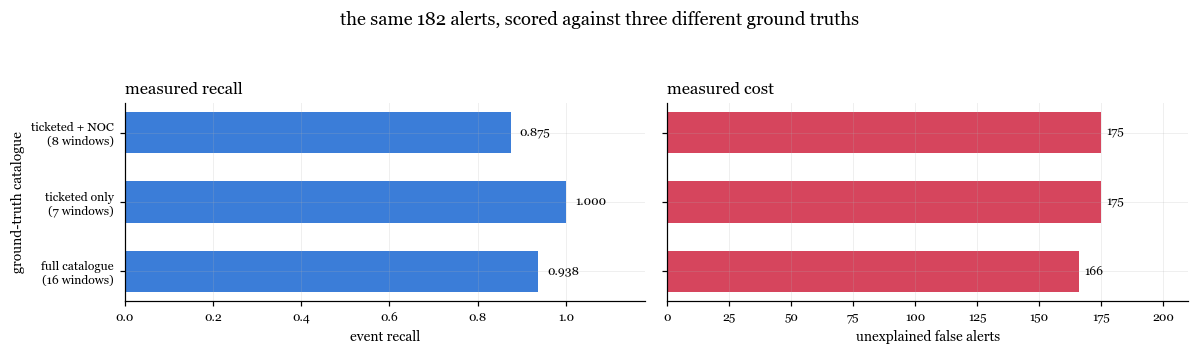

    port_id      port_role           fire_time  peak_score  matched_event  evidence_score_robust  evidence_score_seasonal  evidence_score_broadcast  evidence_score_multicast  evidence_score_pktsize  duration_min
port-id7427    wan-primary 2026-02-01 00:20:00        50.0          False                    0.6                      0.5                      50.0                      50.0                    28.8            10
port-id7428  wan-secondary 2026-02-22 20:10:00        50.0           True                    1.0                      1.5                       3.2                      50.0                     0.6            20
port-id7428  wan-secondary 2026-02-27 14:20:00        50.0           True                    0.8                      1.3                      50.0                      47.3                     7.0            20
port-id7428  wan-secondary 2026-02-06 13:15:00        50.0           True                    2.8                      5.3                      50.0     

In [29]:
TICKETED = ["D", "F", "G"]            # 使用者抱怨過，一定進了 ticket 系統
TICKETED_PLUS = ["D", "E", "F", "G"]  # 再加上 NOC 自己在線路品質報表上查出來的那一件

keys = ["events_total", "events_detected", "event_recall", "event_precision",
        "false_alerts_unexplained", "point_recall"]
rows = []
for name, ids in [("full catalogue", None), ("ticketed only", TICKETED),
                  ("ticketed + NOC", TICKETED_PLUS)]:
    sub = incidents if ids is None else incidents[incidents["event_id"].isin(ids)]
    got, _, _ = evaluate(alerts, sub, SPAN, labels=flags["label"],
                         truth=truth_mask(allp, sub), changes=calendar)
    rows.append({"catalogue": name, "windows": len(sub),
                 **{k: round(got[k], 4) if isinstance(got[k], float) else got[k] for k in keys}})

gt = pd.DataFrame(rows)

fig, axes = plt.subplots(1, 2, figsize=(11, 3.0), sharey=True)
y = np.arange(len(gt))
axes[0].barh(y, gt["event_recall"], color=PALETTE["signal"], height=0.6)
for n, v in enumerate(gt["event_recall"]):
    axes[0].text(v + 0.02, n, f"{v:.3f}", va="center", fontsize=8)
axes[0].set_xlim(0, 1.18)
axes[0].set_yticks(y)
axes[0].set_yticklabels([f"{r.catalogue}\n({r.windows} windows)" for r in gt.itertuples()],
                        fontsize=8)
axes[0].set_xlabel("event recall")
axes[0].set_ylabel("ground-truth catalogue")
axes[0].set_title("measured recall")

axes[1].barh(y, gt["false_alerts_unexplained"], color=PALETTE["alert"], height=0.6)
for n, v in enumerate(gt["false_alerts_unexplained"]):
    axes[1].text(v + 2, n, str(int(v)), va="center", fontsize=8)
axes[1].set_xlim(0, gt["false_alerts_unexplained"].max() * 1.2)
axes[1].set_xlabel("unexplained false alerts")
axes[1].set_title("measured cost")

fig.suptitle("the same 182 alerts, scored against three different ground truths", y=1.06)
fig.tight_layout()
plt.show()

cols = (["port_id", "port_role", "fire_time", "duration_s", "peak_score", "matched_event"]
        + [c for c in al.columns if c.startswith("evidence_")])
top = al.sort_values("peak_score", ascending=False).head(20)[cols].copy()
top["duration_min"] = (top.pop("duration_s") / 60).astype(int)
numeric = top.select_dtypes("number").columns
top[numeric] = top[numeric].round(1)
print(top.to_string(index=False))
print(f"\nof the top 20, {int(top['matched_event'].sum())} overlap a labelled incident window")

## 13. 時間分割驗證（Out-of-Time Validation）與統計不確定性
為避免過度擬合（Overfitting）特定月份的流量特徵，必須將資料依時間切割為訓練段（Tuning Set）與測試段（Test Set）。

### 數據不確定性分析

當 Incident 事件總數極少時（如全月僅 16 個視窗，背後僅代表 8 場獨立事故），單一 Percentile 數字缺乏統計意義。應使用 Clopper-Pearson 確切項式區間（Exact Binomial Interval）或 Bootstrap 進行不確定性估計：

* **視窗層級 (n=16)：** 15/16 命中對應 95% 信心區間為 $[0.698, 0.998]$。
* **事件層級 (n=8)：** 考慮多 Port 同時受創的獨立事件群集，7/8 命中對應 95% 信心區間為 $[0.473, 0.997]$。

跨時間段測試能暴露真實的營運成本波動，防止在測試集上套用過度樂觀的告警參數。

tuned on the first half    threshold 2.5  n_consecutive 3
            detected  n_events  recall  per_day
fold                                           
tune H1            3         3     1.0   11.403
test H2           13        13     1.0   13.070
full month        16        16     1.0   12.235

tuned on the second half   threshold 8  n_consecutive 3
            detected  n_events  recall  per_day
fold                                           
tune H1            2         3   0.667    0.467
test H2           13        13   1.000    1.200
full month        15        16   0.938    0.833

shipped                    threshold 4  n_consecutive 2
            detected  n_events  recall  per_day
fold                                           
tune H1            2         3   0.667    6.068
test H2           13        13   1.000    6.068
full month        15        16   0.938    6.067

bootstrap over 16 windows   mean 0.9364   95% [0.8125, 1.0000]   sd 0.0613
bootstrap over  8 events    mean

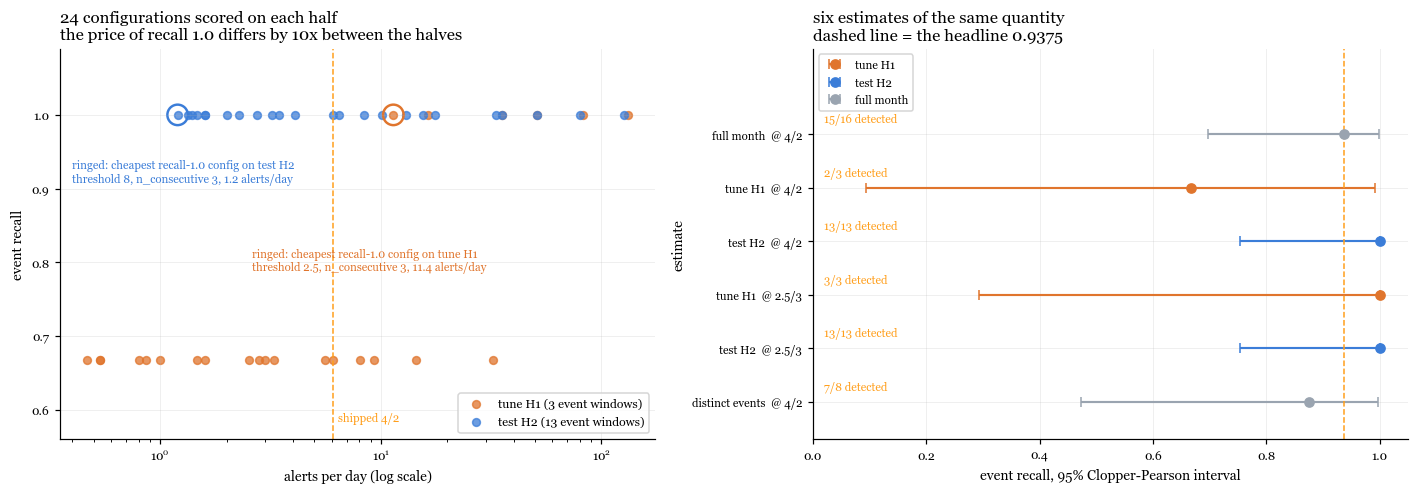

In [30]:
# 時間切分。分數欄位不重算，只有「決策參數」被關進第一半，第二半完全沒有參與選參。
from scipy.stats import beta as _beta

SPLIT_AT = pd.Timestamp("2026-02-16 00:00")
holdout_folds = {
    "tune H1": allp["timestamp"] < SPLIT_AT,
    "test H2": allp["timestamp"] >= SPLIT_AT,
    "full month": pd.Series(True, index=allp.index),
}


def holdout_run(mask, thr, n_consec):
    """Rebuild layers 2 and 3 inside one time slice, and score that slice only."""
    sub = allp.loc[mask, ["timestamp", "device_id", "port_id", "port_role",
                          "packets_pps", "score_max"]].copy()
    sub["_lab"] = confirm(sub["score_max"], thr, n_consecutive=n_consec,
                          direction="high")["label"]
    lo, hi = sub["timestamp"].min(), sub["timestamp"].max()
    inside = incidents[(incidents["start"] >= lo) & (incidents["start"] <= hi)]
    # policy 只提供 layer 3 的欄位，min_consecutive 不參與 build_alerts，
    # 連續次數在上面的 confirm() 決定，所以這裡沿用出廠 policy 不會互相打架。
    made = build_alerts(sub, "_lab", "score_max", policy=policy, cadence_s=CADENCE,
                        changes=calendar, method="holdout")
    got, per_event, _ = evaluate(made, inside, (lo, hi), changes=calendar)
    return got, per_event


holdout_grid = pd.DataFrame([
    dict(fold=name, threshold=thr, n_consecutive=nc,
         n_events=g["events_total"], detected=g["events_detected"],
         recall=g["event_recall"], per_day=g["alerts_per_day"])
    for name, mask in holdout_folds.items()
    for thr in [2.5, 3.0, 3.5, 4.0, 5.0, 6.0, 8.0, 12.0]
    for nc in [1, 2, 3]
    for g in [holdout_run(mask, thr, nc)[0]]
])


def cheapest(fold):
    """The selection rule a cadet actually uses: best recall first, fewest alerts second."""
    d = holdout_grid[holdout_grid["fold"] == fold]
    d = d[d["recall"] >= d["recall"].max() - 1e-9]
    win = d.sort_values("per_day").iloc[0]
    return float(win["threshold"]), int(win["n_consecutive"])


def cross(cfg):
    """One configuration read on all three folds."""
    d = holdout_grid[(holdout_grid["threshold"] == cfg[0])
                     & (holdout_grid["n_consecutive"] == cfg[1])]
    return d.set_index("fold")[["detected", "n_events", "recall", "per_day"]]


tuned_h1, tuned_h2 = cheapest("tune H1"), cheapest("test H2")
for tag, cfg in [("tuned on the first half ", tuned_h1),
                 ("tuned on the second half", tuned_h2),
                 ("shipped                 ", (THRESHOLD, N_CONSEC))]:
    print(f"{tag}   threshold {cfg[0]:g}  n_consecutive {cfg[1]}")
    print(cross(cfg).round(3).to_string())
    print()


def cp_interval(k, n, alpha=0.05):
    """Clopper-Pearson exact binomial interval, the honest one when n is 16."""
    lo = 0.0 if k == 0 else float(_beta.ppf(alpha / 2, k, n - k + 1))
    hi = 1.0 if k == n else float(_beta.ppf(1 - alpha / 2, k + 1, n - k))
    return lo, hi


est_rows = []
for fold, cfg in [("full month", (THRESHOLD, N_CONSEC)),
                  ("tune H1", (THRESHOLD, N_CONSEC)),
                  ("test H2", (THRESHOLD, N_CONSEC)),
                  ("tune H1", tuned_h1),
                  ("test H2", tuned_h1)]:
    r = cross(cfg).loc[fold]
    k, n = int(r["detected"]), int(r["n_events"])
    lo, hi = cp_interval(k, n)
    est_rows.append({"label": f"{fold}  @ {cfg[0]:g}/{cfg[1]}", "group": fold,
                     "k": k, "n": n, "recall": k / n, "lo": lo, "hi": hi})

# 16 個視窗背後只有 8 個獨立事件，G 與 H 各佔 5 個 port，重複計數會把分母灌水。
per_ev = holdout_run(holdout_folds["full month"], THRESHOLD, N_CONSEC)[1]
by_event = per_ev.groupby("event_id")["detected"].agg(["sum", "size"])
k8, n8 = int((by_event["sum"] > 0).sum()), len(by_event)
lo8, hi8 = cp_interval(k8, n8)
est_rows.append({"label": f"distinct events  @ {THRESHOLD:g}/{N_CONSEC}", "group": "full month",
                 "k": k8, "n": n8, "recall": k8 / n8, "lo": lo8, "hi": hi8})
est = pd.DataFrame(est_rows)

rng = np.random.default_rng(7)
detected_flags = per_ev["detected"].to_numpy(bool)
ids = per_ev["event_id"].to_numpy()
uids = np.unique(ids)
n16 = len(detected_flags)
boot_window = np.array([detected_flags[rng.integers(0, n16, n16)].mean()
                        for _ in range(2000)])
boot_event = np.array([
    np.concatenate([detected_flags[ids == u]
                    for u in uids[rng.integers(0, len(uids), len(uids))]]).mean()
    for _ in range(2000)])
for nm, arr in [("bootstrap over 16 windows", boot_window),
                ("bootstrap over  8 events ", boot_event)]:
    print(f"{nm}   mean {arr.mean():.4f}   95% [{np.percentile(arr, 2.5):.4f}, "
          f"{np.percentile(arr, 97.5):.4f}]   sd {arr.std():.4f}")

fig, axes = plt.subplots(1, 2, figsize=(13, 4.6))

ax = axes[0]
for fold, colour in [("tune H1", PALETTE["baseline"]), ("test H2", PALETTE["signal"])]:
    d = holdout_grid[holdout_grid["fold"] == fold]
    ax.scatter(d["per_day"], d["recall"], s=26, alpha=0.75, color=colour,
               label=f"{fold} ({int(d['n_events'].iloc[0])} event windows)")
for cfg, fold, colour, at in [(tuned_h2, "test H2", PALETTE["signal"], (0.40, 0.94)),
                              (tuned_h1, "tune H1", PALETTE["baseline"], (2.60, 0.82))]:
    r = cross(cfg).loc[fold]
    ax.scatter([r["per_day"]], [r["recall"]], s=180, facecolors="none",
               edgecolors=colour, linewidths=1.6)
    ax.text(at[0], at[1], f"ringed: cheapest recall-1.0 config on {fold}\n"
            f"threshold {cfg[0]:g}, n_consecutive {cfg[1]}, {r['per_day']:.1f} alerts/day",
            fontsize=7.5, color=colour, va="top")
shipped_rate = float(cross((THRESHOLD, N_CONSEC)).loc["full month", "per_day"])
ax.axvline(shipped_rate, color=PALETTE["truth"], ls="--", lw=1.0)
ax.text(shipped_rate * 1.06, 0.585, f"shipped {THRESHOLD:g}/{N_CONSEC}",
        fontsize=7.5, color=PALETTE["truth"])
ax.set_xscale("log")
ax.set_xlabel("alerts per day (log scale)")
ax.set_ylabel("event recall")
ax.set_ylim(0.56, 1.09)
ax.set_title("24 configurations scored on each half\n"
             "the price of recall 1.0 differs by 10x between the halves")
ax.legend(loc="lower right")

ax = axes[1]
colours = {"tune H1": PALETTE["baseline"], "test H2": PALETTE["signal"],
           "full month": PALETTE["muted"]}
ypos = np.arange(len(est))[::-1]
for grp, colour in colours.items():
    sel = (est["group"] == grp).to_numpy()
    if not sel.any():
        continue
    ax.errorbar(est.loc[sel, "recall"], ypos[sel],
                xerr=[(est.loc[sel, "recall"] - est.loc[sel, "lo"]).to_numpy(),
                      (est.loc[sel, "hi"] - est.loc[sel, "recall"]).to_numpy()],
                fmt="o", ms=6, lw=1.4, capsize=3, color=colour, label=grp)
for n, r in enumerate(est.itertuples()):
    ax.text(0.02, ypos[n] + 0.22, f"{r.k}/{r.n} detected", fontsize=7.5,
            color=PALETTE["truth"])
ax.axvline(float(est["recall"].iloc[0]), color=PALETTE["truth"], ls="--", lw=1.0)
ax.set_yticks(ypos)
ax.set_yticklabels(est["label"], fontsize=7.5)
ax.set_xlim(0, 1.05)
ax.set_ylim(-0.7, len(est) + 0.6)
ax.set_xlabel("event recall, 95% Clopper-Pearson interval")
ax.set_ylabel("estimate")
ax.set_title("six estimates of the same quantity\n"
             "dashed line = the headline 0.9375")
ax.legend(loc="upper left", fontsize=7.5)

fig.tight_layout()
plt.show()

### **消融實驗（Ablation Study）:**

* Parameter：`SPLIT_AT`（切分時間點），換一個日期會改變前後兩段各自的樣本數與結論穩不穩。
* Architecture：這裡用的是單一時間切分；也可以改成滾動視窗（rolling-origin）或多摺交叉驗證，是另一種驗證設計。
* Per-port：目前切分套用到全體 port 的合併資料；個別 port 的流量模式如果差異很大，也可以各自切分驗證。

## 14. 整合掛載： Grafana 告警與維護機制

本節將前述設計的規則、維護時窗與通知範本實體化至 Grafana 系統中。執行前需先啟動以下基礎服務：

| 元件名稱 | 預設位址 | 系統功能與依賴關係 |
| --- | --- | --- |
| **Prometheus** | `http://localhost:9090` | 儲存並提供 `net:*` Recording Rules 查詢。 |
| **node_exporter** | `http://localhost:9100/metrics` | 提供基礎網路數據源（Windows 環境使用 `windows_exporter`:9182）。 |
| **Grafana** | `http://localhost:3000` | 告警規則（Alert Rules）、靜音時窗（Mute Timings）與通知範本（Templates）載體。 |
| **`detector.py`** | `http://localhost:9200/metrics` | 外部 Python 服務，計算偏離分數並暴露 `TrafficAnomaly` 指標。 |

> **啟動指令：** 於專案根目錄執行 `python labs/workshop/detector.py` 並保持背景運作。

### 14a. 告警規則設定 (Alert Rule)

建置步驟：

1. **語法驗證：** 於 Grafana **Explore** 介面測試 PromQL Query（確保 `net:avg_pkt_bytes` 與 `net:packets_pps` 皆能正常回傳數據），嚴禁於告警編輯器內進行 Query 除錯。
2. **建立規則：** 前往 **Alerting > Alert rules > New alert rule** 填入設定：
   * **Rule Name：** 填入具體描述名稱（如 `SmallPacketFlood`）。
   * **A 段 (Data Source)：** 選擇 Prometheus，切換至 `Code` 模式貼入 PromQL。
   * **B 段 (Reduce)：** 設定數據聚合邏輯（選用 `last` 或 `min`）。
   * **C 段 (Threshold)：** 設定判定條件（如 `IS BELOW 200`）。
   * **Evaluation Group & Interval：** 設定評估週期與資料夾結構。
   * **Pending Period (`for`)：** 設定轉為 `Firing` 狀態前的延遲確認時間。
   * **Labels & Annotations：** 加入 `severity` 標籤與 `summary` 註解（使用 `{{ $labels.device }}` 變數）。
3. **觸發測試：** 執行大檔下載指令模擬異常流量（如 `curl -o /dev/null https://speed.cloudflare.com/__down?bytes=500000000`），觀察告警狀態由 `Normal` 轉為 `Pending`，並於維持滿 Pending Period 後正式進入 `Firing`。

### 14b. 維護時窗靜音設定 (Mute Timing)

前往 **Alerting > Notification policies > Time intervals**，編輯 `aiops-maintenance-window`：

* **時間設定：** 將時間範圍修訂為 `02:00` 至 `05:00`。
* **時區處理（IANA Timezone）：** `Location` 欄位保持空白預設為 UTC 時區。跨時區團隊需明確指定時區字串以防時間偏移。

### 14c. 告警通知範本格式化 (Notification Template)

前往 **Alerting > Contact points**，編輯預設通知管道之 **Message** 欄位：

```text
{{ range .Alerts }}
{{ .Annotations.summary }}
  instance   {{ .Labels.device }}
  detail     {{ .Annotations.description }}
  version    {{ .Annotations.rule_version }}
  started    {{ .StartsAt }}
{{ end }}
```

#### 變數語法與求值時機差異

* **告警規則內部 (Alert Rule Annotations)：** 使用 `{{ $values.B }}` 與 `{{ $labels.device }}`，於規則求值時（Evaluation Time）即時展開。
* **通知管道內部 (Contact Point Message)：** 使用 `{{ .Annotations.x }}` 與 `{{ .Labels.x }}`，於發送通知時（Dispatch Time）解析。

*註：`node_exporter` 導出的裝置標籤名稱為 `device`，若於範本中誤寫為 `port_id` 將導致變數輸出空白。*

## 15. 系統收尾與整合說明
新增的自訂告警規則需予以保留，作為系統運作的基準線。

本實驗採用的門檻參數、營運策略以及 Lab 01 提煉的非參數 Baseline（Median / MAD），共同構成新版 `rolling_zscore()` 的核心演算法。由於系統管道（Pipeline）已於 Lab 00 完成架構解耦，直接替換該演算法函式並重啟 `detector.py` 後，Grafana 端的偏離分數與告警判定將同步更新，下游架構無須進行任何修訂。

> **收尾：** 若第 14 節啟動了 `detector.py`、Prometheus、node_exporter 或 Grafana，且沒有計畫繼續在上面操作，下面兩格可以檢查、關閉，避免它們在背景持續佔用連接埠、持續刮取與計算。

### 治理：閾值是商業決策，不是工程常數

把閾值從 4.0 調到 3.0，多抓一個事件，代價是每月多幾百則告警。這是一個包著設定值外殼的商業決策，通常由寫偵測程式的人預設拍板，沒有對成本負責的人簽字。四個該直接問維運團隊的問題：

1. **權衡率：** 一個錯過的事件值多少個告警？這個數字是從人力、班表、每則告警的處理時間推出來的，還是用猜的？
2. **決策權：** 誰設定這個權衡，記錄在哪裡，誰簽核變更？
3. **不對稱代價：** 核心線路（`wan-primary`）漏抓一次，跟備援儲存（`backup-storage`）漏抓一次，代價一樣嗎？§9 的 `role_weight` 是管線目前唯一表達這種差異的機制。
4. **退場標準：** 什麼證據能證明關掉一條規則是合理的？沒有退場條件，規則只會無限期累積，沒有人有立場移除它們。

### 收尾：七個可以搬到任何資料科學專案的原則

這門課的載體是異常偵測。走過 Lab 01、Lab 02 這一路，資料語意、特徵工程、baseline 選擇、confirm、alert policy、記分卡、時間切分驗證，踩過的坑可以濃縮成七條跟異常偵測本身無關的通則：

1. **資料語意先於統計方法。** 欄位語意搞錯（把差值當計數器），下游所有統計上嚴謹的計算，做對的都是一個錯誤的量。
2. **沒有萬用特徵，也沒有萬用 baseline。** 每一種都只覆蓋異常分類學裡的一塊；該問的是「這個方法覆蓋了哪一塊，把哪一塊留給了誰」，不是「哪個最好」。
3. **穩健統計的代價是效率，不是免費的升級。** median/MAD 抗污染，但在乾淨資料上的統計效率較低，任何「更穩健」的設計都要核算這個代價。
4. **極端類別不平衡下，準確率是會說謊的指標。** 選錯評估指標本身就是一個帶著下游所有調參方向走偏的設計決定。
5. **閾值是商業決策，不是等待被發現的數學常數。** 任何看起來客觀的門檻背後都藏著一個成本權衡。
6. **一個四位小數的 recall，通常撐不起它自己的精確度。** 樣本量、時間切分、標籤完整性三者一起決定一個評估數字有沒有資格被引用。
7. **管線每一層都必須是可獨立驗證與替換的模組。** 特徵、baseline、維運策略三層的獨立性，讓設計本身成為可信賴的基礎，可靠性來自模組化架構，不是任何單一部件的複雜度。

In [31]:
import time
import subprocess, sys

STOP_SERVICES = False  # flip to True and re-run this cell when you are actually done

DETECTOR_PORT = 9200  # detector.py's default port, Lab 00 §5
STOP_TARGETS = [
    ("Prometheus", 9090),
    ("node_exporter" if sys.platform != "win32" else "windows_exporter", 9100 if sys.platform != "win32" else 9182),
    ("Grafana", 3000),
    ("detector.py", DETECTOR_PORT),
]

def _pids_on_port(port):
    """Best-effort, cross-platform: PIDs of whatever is listening on `port`."""
    try:
        if sys.platform == "win32":
            out = subprocess.run(["netstat", "-ano"], capture_output=True, text=True).stdout
            return sorted({ln.split()[-1] for ln in out.splitlines()
                          if f":{port} " in ln and "LISTENING" in ln})
        out = subprocess.run(["lsof", "-ti", f":{port}"], capture_output=True, text=True).stdout
        return sorted({p for p in out.split() if p})
    except FileNotFoundError:
        return []

if not STOP_SERVICES:
    print("STOP_SERVICES is False, nothing done. Set it to True above and re-run this cell to actually stop them.")
else:
    def _kill(pid):
        if sys.platform == "win32":
            subprocess.run(["taskkill", "/F", "/PID", pid], capture_output=True)
        else:
            subprocess.run(["kill", pid], capture_output=True)

    for name, port in STOP_TARGETS:
        for pid in _pids_on_port(port):
            print(f"stopping {name} on :{port}  pid {pid}")
            _kill(pid)

    time.sleep(1)
    for name, port in STOP_TARGETS:
        state = "still up" if _pids_on_port(port) else "stopped"
        print(f"  {state:<10} {name:<16} :{port}")

found = False
for name, port in STOP_TARGETS:
    pids = _pids_on_port(port)
    if pids:
        found = True
        print(f"  {name:<16} :{port:<6} pid(s) {', '.join(pids)}")
if not found:
    print("  nothing on these ports right now, already clean")


STOP_SERVICES is False, nothing done. Set it to True above and re-run this cell to actually stop them.
  Grafana          :3000   pid(s) 58922
